In [74]:
%reset -f
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
print("REPO_ROOT:", REPO_ROOT)

import mplhep as hep
import numpy as np
import pandas as pd
import torch
import yaml
from matplotlib import pyplot as plt
from scipy.stats import ks_2samp

from model import LightningWBoson
from physics.diagnostics import component_calibration
from physics.physics import (
    TOR,
    W_MASS,
    dphi,
    four_vector_pairs,
    invariant_mass,
    invariant_mass2,
    pt,
    sphi,
)
from physics.selection import JET_ENERGY_COLUMNS, lepton_p4, selection_masks
from physics.torchBoost import Booster as TorchBooster
from train import train
from notebooks.plottingtool import (
    plot_1d_hist,
    plot_2d_hist,
    plot_angular_1d_grid,
    plot_angular_2d_grid,
    plot_gradient_cosine_heatmaps,
    plot_gradient_norms,
    plot_loss_curves,
    plot_pair,
    save_figure,
)
hep.style.use("ATLAS")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
REPO_ROOT: /root/work/ww-pcres


In [75]:
# The tuned k-fold run: RUN_DIR/fold<i>, picked by the fold0 glob below.
CONFIG_PATH = REPO_ROOT / "configs/kfold_config.yaml"
# The untuned production k-fold run, same layout:
# CONFIG_PATH = REPO_ROOT / "configs/untuned_kfold_config.yaml"
# Single fold-1 models staged for a paired tuned/untuned comparison:
# CONFIG_PATH = REPO_ROOT / "sweep/outputs/visualize/tuned_fold1.yaml"
# CONFIG_PATH = REPO_ROOT / "sweep/outputs/visualize/untuned_fold1.yaml"
# A single-model run from 2026-09-17 (6 attention blocks, no bias penalty):
# CONFIG_PATH = REPO_ROOT / "configs/config.yaml"
cfg = yaml.safe_load(CONFIG_PATH.read_text())

# "latest" prefers last.ckpt; "best" reads the monitored metric out of the filename.
CKPT_SELECTION = "best"

RUN_DIR = Path(cfg["paths"]["saved_path"]).expanduser()
if not RUN_DIR.is_absolute():
    RUN_DIR = (REPO_ROOT / RUN_DIR).resolve()
FIGURE_DIR = RUN_DIR / "figure"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("Saving figures to:", FIGURE_DIR)


def save_figure_pair(figures, stem):
    """Save the 1D and 2D views returned by plot_pair."""
    for figure, suffix in zip(figures, ("1d", "2d")):
        save_figure(figure, FIGURE_DIR, f"{stem}_{suffix}")

# Cross-fitting runs write one model per fold under saved_path/fold<i>; a plain
# single-model run writes saved_path/logs directly.
LOG_ROOT = next(iter(sorted(RUN_DIR.glob("fold0"))), RUN_DIR)
print("Using log root:", LOG_ROOT)

ckpt_files = sorted(
    (LOG_ROOT / "logs").glob("version_*/checkpoints/*.ckpt"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoint files found under {LOG_ROOT}")
epoch_ckpts = [path for path in ckpt_files if path.name != "last.ckpt"] or ckpt_files


def best_ckpt_by_metric(paths, cfg):
    """Checkpoint with the best monitored metric in its filename, or None if unlabelled."""
    trainer_cfg = cfg.get("trainer", {})
    mode = trainer_cfg.get("monitor_mode", "min")
    monitored = trainer_cfg.get("monitor_metric", "val_static_loss")

    for metric in [monitored, "val_static_loss", "val_loss"]:
        token = f"{metric}="
        scored = []
        for path in paths:
            if token not in path.stem:
                continue
            try:
                scored.append((path, float(path.stem.rsplit(token, 1)[1].split("-", 1)[0])))
            except ValueError:
                pass
        if scored:
            path, value = sorted(scored, key=lambda item: item[1], reverse=(mode == "max"))[0]
            return path, f"best by {metric} ({value:.4g})"
    return None


if CKPT_SELECTION == "latest":
    ckpt_path = next((path for path in ckpt_files if path.name == "last.ckpt"), epoch_ckpts[0])
    reason = "most recent"
elif CKPT_SELECTION == "best":
    # Falls back to the newest epoch checkpoint when no filename carries the metric.
    ckpt_path, reason = best_ckpt_by_metric(epoch_ckpts, cfg) or (epoch_ckpts[0], "most recent")
else:
    raise ValueError(f"CKPT_SELECTION must be 'best' or 'latest', got {CKPT_SELECTION!r}")

LOG_DIR = ckpt_path.parents[1]
print(f"Run directory: {LOG_ROOT} ({len(ckpt_files)} checkpoints found)")
print(f"Using {reason} checkpoint: {ckpt_path}")
print(f"Using log directory: {LOG_DIR}")

Saving figures to: /root/work/ww-pcres/fold_meta_ggF_tuned_v2/figure
Using log root: /root/work/ww-pcres/fold_meta_ggF_tuned_v2/fold0
Run directory: /root/work/ww-pcres/fold_meta_ggF_tuned_v2/fold0 (2 checkpoints found)
Using best by val_loss (19.56) checkpoint: /root/work/ww-pcres/fold_meta_ggF_tuned_v2/fold0/logs/version_0/checkpoints/reg-epoch=184-val_loss=19.56.ckpt
Using log directory: /root/work/ww-pcres/fold_meta_ggF_tuned_v2/fold0/logs/version_0


Using metrics file: /root/work/ww-pcres/fold_meta_ggF_tuned_v2/fold0/logs/version_0/metrics.csv
Best loss values at best epoch 184.0 (min val_loss):
            component     train       val weighted_train weighted_val
                total   19.3372   19.5645                            
         $W$ 4-vec L1   28.4749   28.6403        16.0454      16.1385
       $W$ 4-vec bias 0.0186322 0.0184936       0.166341     0.165103
      Joint $m_W$ MMD 0.0166475 0.0297162       0.237813     0.424502
          Angular MMD 0.0122751 0.0119191        1.30759      1.26967
$\Delta \mathrm{MET}$        15   14.8727        1.58007      1.56665
Unavailable train/validation pairs: $H$ 4-vec L1, $m_H$ L1, $\alpha$ MMD, $m_W$ L1


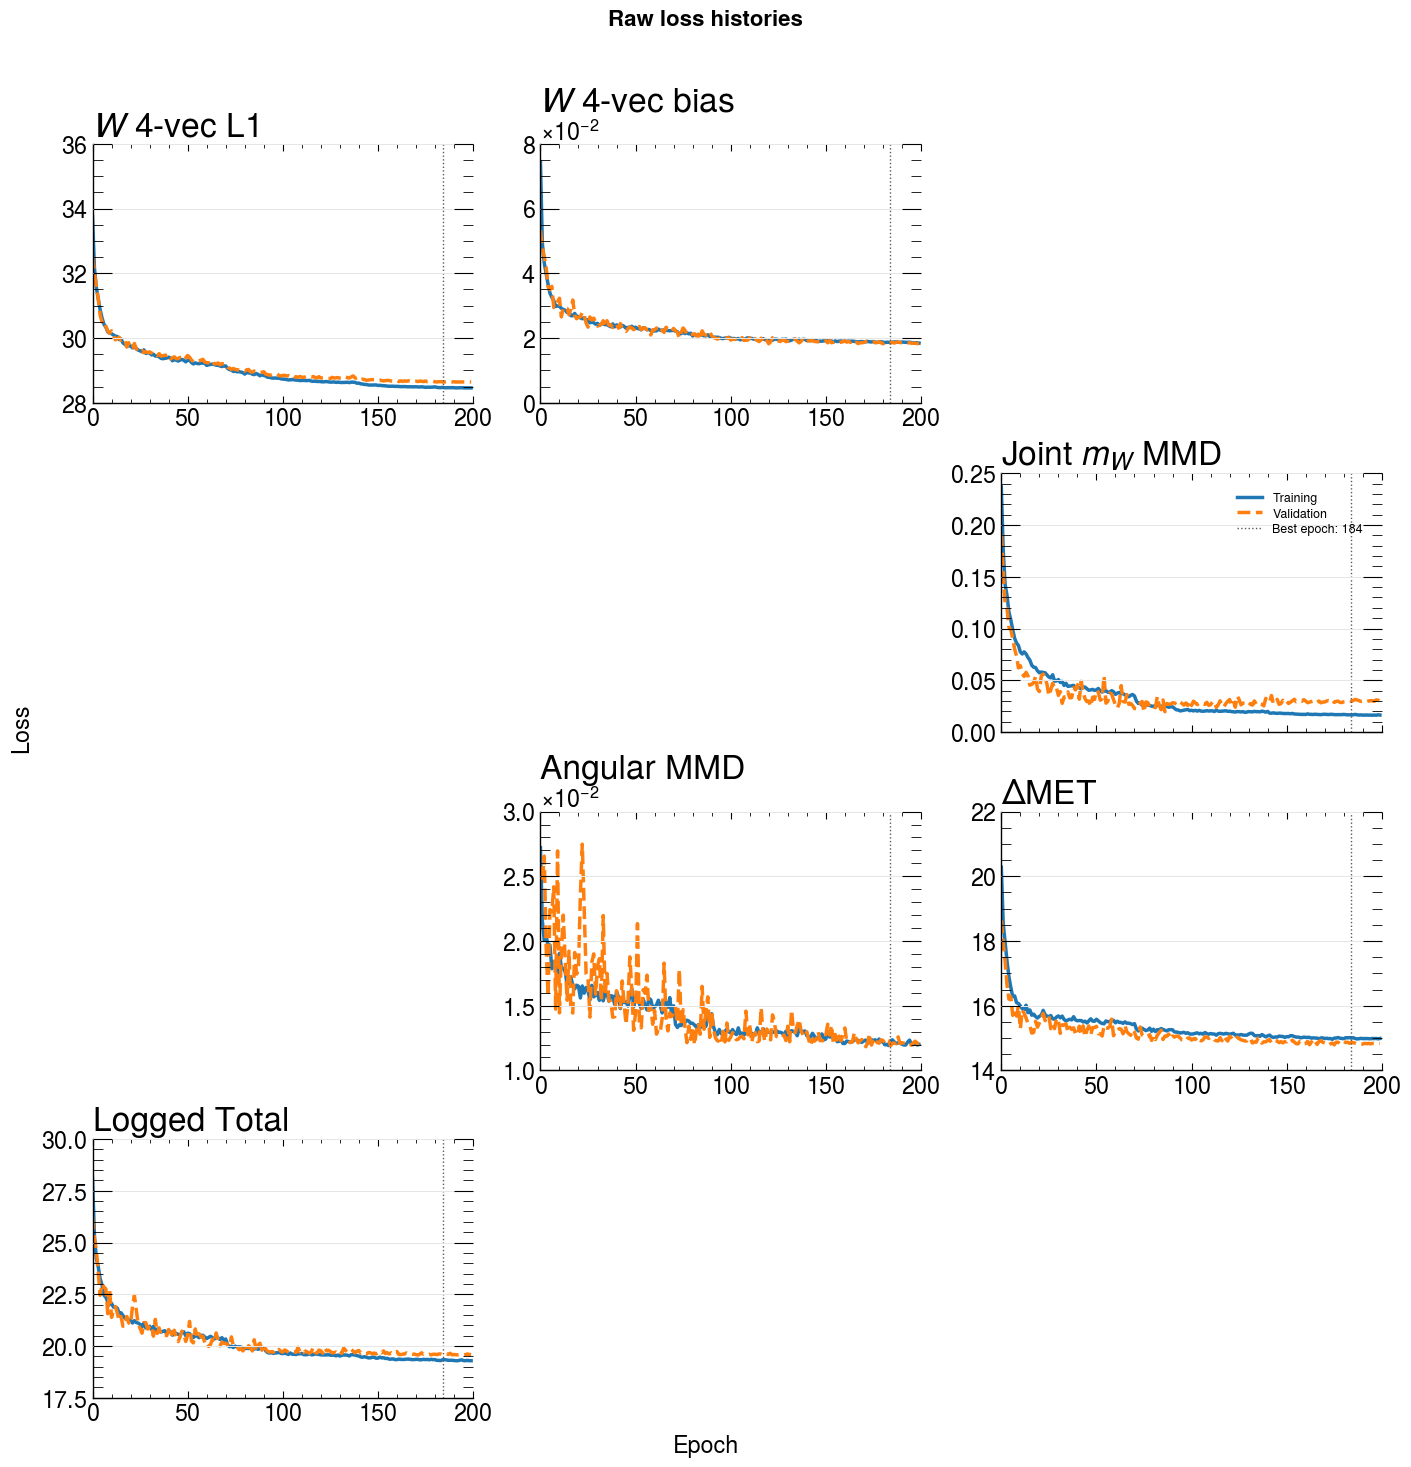

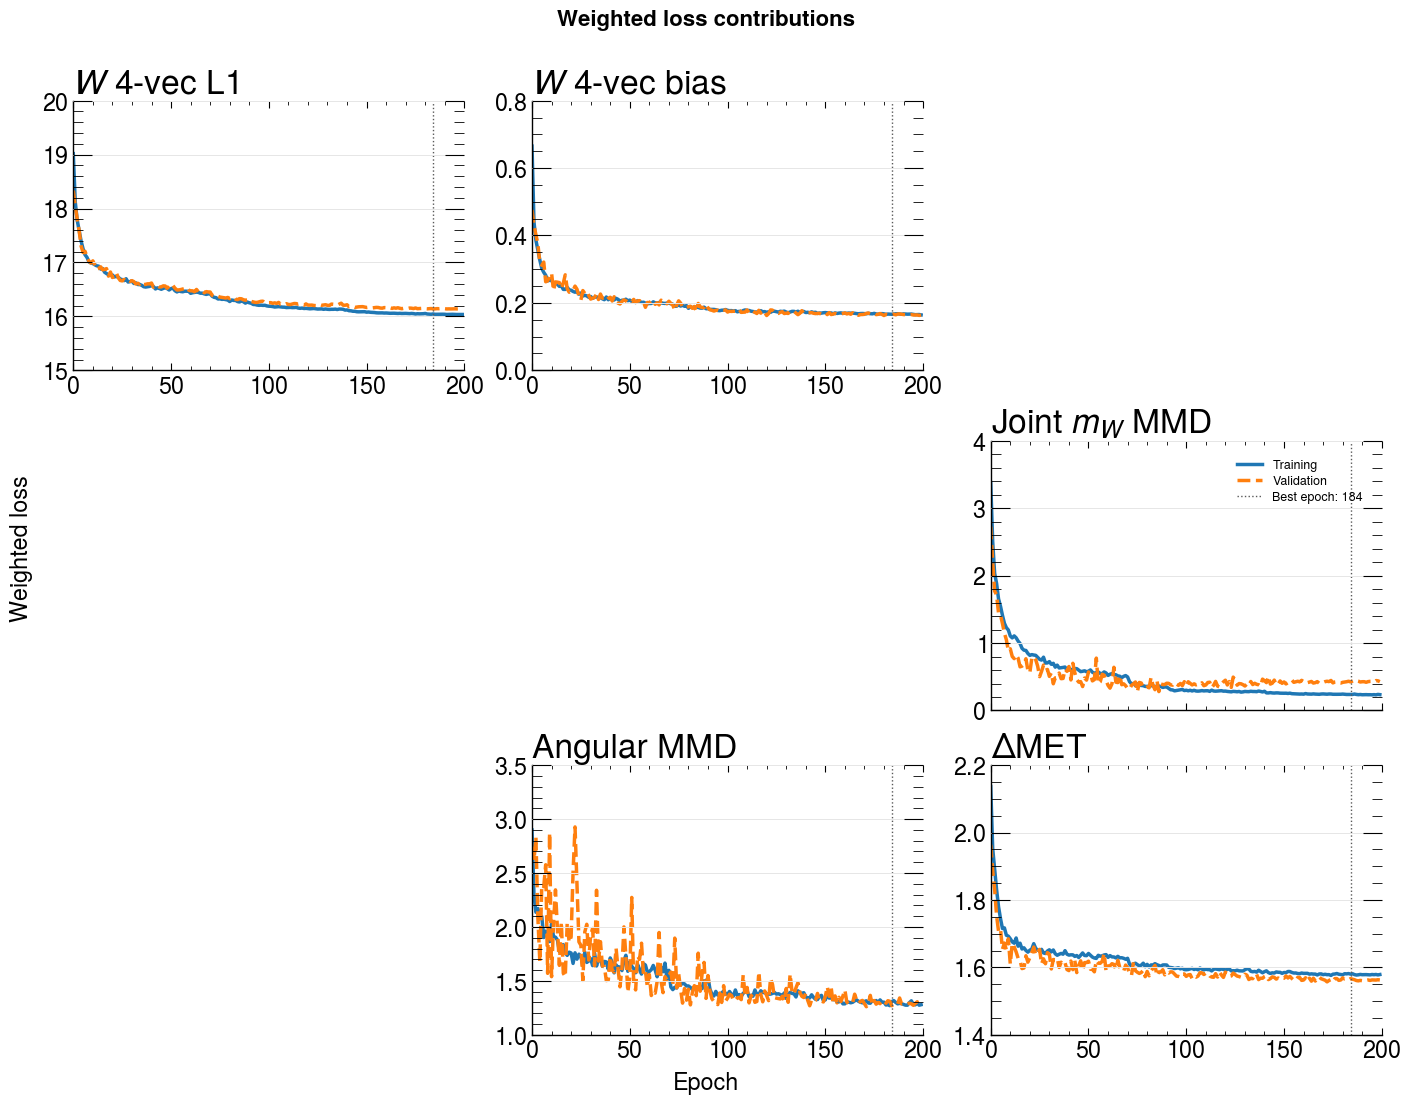

No grad_cos columns found in metrics. Enable parameters.log_loss_gradient_cosines and rerun training.
No populated grad_norm columns found. Enable parameters.log_loss_gradient_cosines and rerun training with the current logging implementation.


In [76]:
METRICS_PATH = LOG_DIR / "metrics.csv"
metrics = pd.read_csv(METRICS_PATH)

loss_diagnostics = plot_loss_curves(METRICS_PATH, cfg)
if loss_diagnostics is not None:
    for figure, filename in zip(loss_diagnostics["figures"], ("loss_raw", "loss_weighted")):
        save_figure(figure, FIGURE_DIR, filename)

gradient_cosine_figures = plot_gradient_cosine_heatmaps(metrics)
for filename, figure in gradient_cosine_figures.items():
    save_figure(figure, FIGURE_DIR, filename)

gradient_norms = plot_gradient_norms(metrics)
if gradient_norms is not None:
    save_figure(gradient_norms, FIGURE_DIR, "gradient_norms")

In [77]:
# Reuse the data split defined by the training config.
dm = train.main(train=False, config_path=str(CONFIG_PATH))

model = LightningWBoson.load_from_checkpoint(str(ckpt_path), weights_only=False, strict=False)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Inference covers the whole test set so cuts can be retuned without re-running it.
feature_batches = []
prediction_batches = []
target_batches = []

with torch.no_grad():
    for inputs, targets in dm.test_dataloader():
        inputs = inputs.to(device)
        feature_batches.append(inputs.cpu().numpy())
        prediction_batches.append(model(inputs).cpu().numpy())
        target_batches.append(targets.numpy())

all_features = np.concatenate(feature_batches, axis=0)
all_predictions = np.concatenate(prediction_batches, axis=0)
all_true_labels = np.concatenate(target_batches, axis=0)
print(f"Evaluated {len(all_predictions)} test events on {device}.")

Seed set to 2330


Using original pre-split HDF5 data
Train category: ggF_train
Val category: ggF_val
Test category: ggF_test
Using HDF5 categories: ggF_train
Training objects shape: (981421, 18)
Target objects shape: (981421, 10)
Removed 675 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Removed 100 rows with a dilepton mass of 125.0 GeV or more
Using HDF5 categories: ggF_val
Training objects shape: (280152, 18)
Target objects shape: (280152, 10)
Removed 196 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Removed 28 rows with a dilepton mass of 125.0 GeV or more
Using HDF5 categories: ggF_test
Training objects shape: (140669, 18)
Target objects shape: (140669, 10)
Removed 97 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Removed 7 rows with a dilepton mass of 125.0 GeV or more
Using 4 workers in data loading.
Train split: 980646 samples
Validation split: 279928 samples
Test split: 140565 samples
Fe

In [78]:
# Cut thresholds live in physics/selection.py so they stay unit tested.
NJETS_SELECTION = None  # 0 / 1 / 2 keeps only that jet multiplicity; None keeps every event

masks = selection_masks(all_features, njets=NJETS_SELECTION)

# No cut is applied by default; narrow the sample with e.g. selection &= masks["met"].
selection = np.ones(len(all_features), dtype=bool)
selection &= masks["n_jets"]
# selection &= masks["l0_pt"]
# selection &= masks["l1_pt"]
# selection &= masks["pre_mll"]

features = all_features[selection]
predictions = all_predictions[selection]
true_labels = all_true_labels[selection]
print(
    f"Selected {len(features)} / {len(all_features)} events "
    f"(njets selection: {NJETS_SELECTION})."
)

Selected 140565 / 140565 events (njets selection: None).


In [79]:
CHARGES = ["+", "-"]

# Leptons, W bosons and the targets, as (events, {+, -}, {px, py, pz, E}).
lep_p4 = lepton_p4(features)
met = features[:, 16:18]  # (px, py)
pred_w_p4 = four_vector_pairs(predictions[:, 0:8])
true_w_p4 = four_vector_pairs(true_labels[:, 0:8])
true_w_mass = np.abs(true_labels[:, 8:10])  # the targets carry the W masses separately

# Each neutrino is its W minus the measured lepton; the Higgs is the W pair.
pred_nu_p4 = pred_w_p4 - lep_p4
true_nu_p4 = true_w_p4 - lep_p4
pred_higgs_p4 = pred_w_p4.sum(axis=1)
true_higgs_p4 = true_w_p4.sum(axis=1)
pred_higgs_mass = invariant_mass(pred_higgs_p4)
true_higgs_mass = invariant_mass(true_higgs_p4)

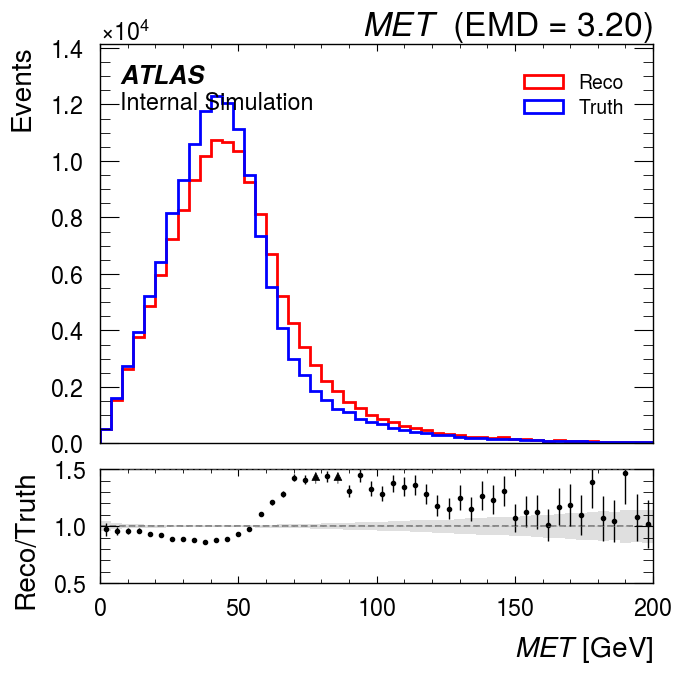

Rel err < 20%: 41.27 %


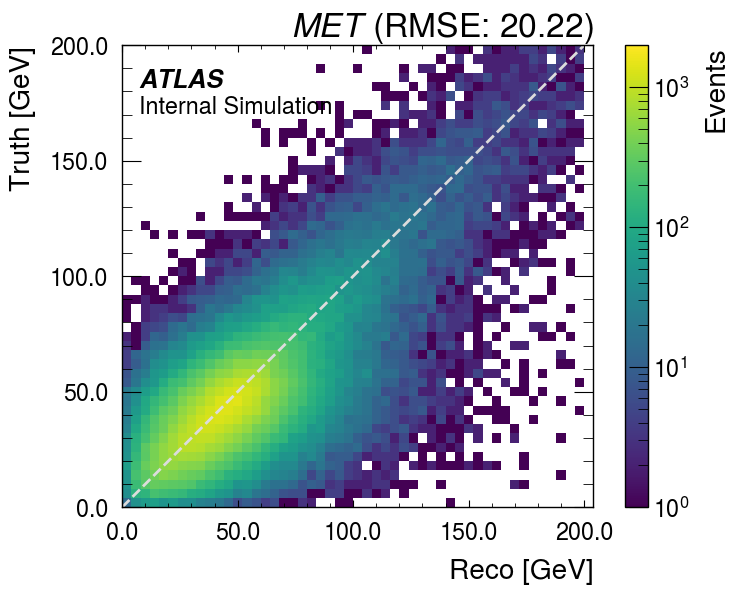

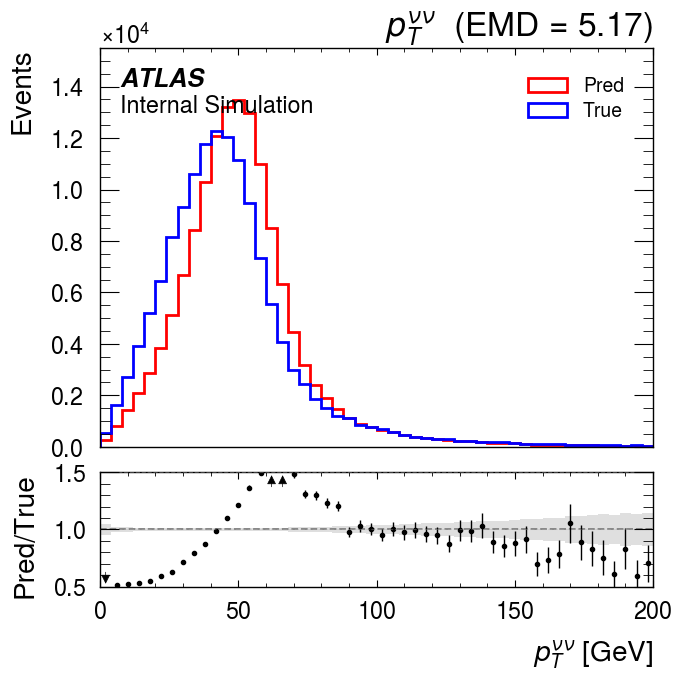

Rel err < 20%: 44.45 %


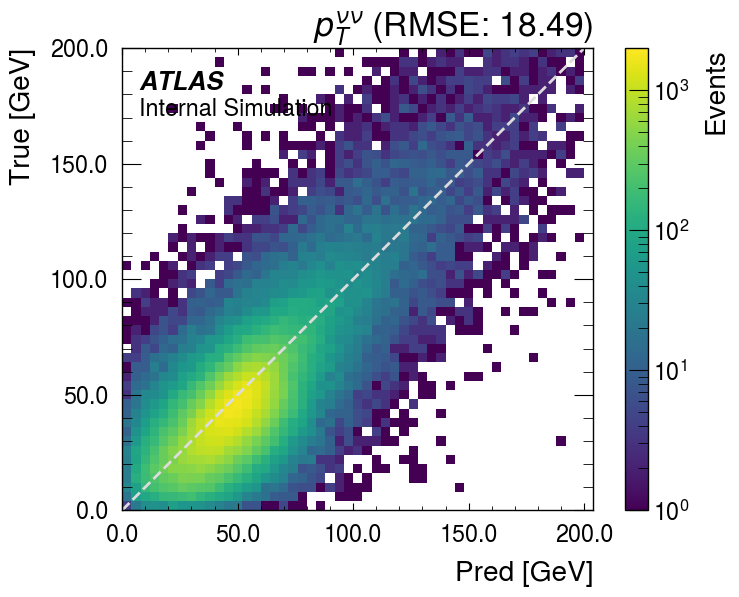

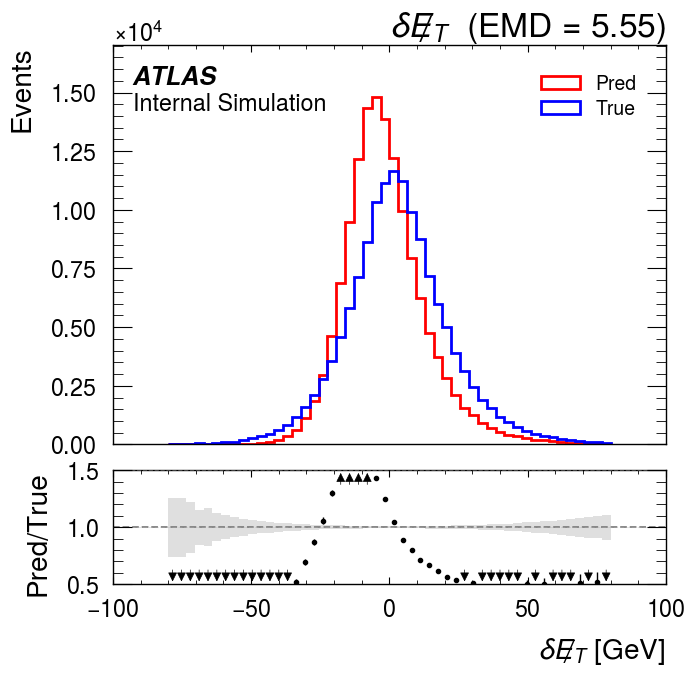

Rel err < 20%: 11.13 %


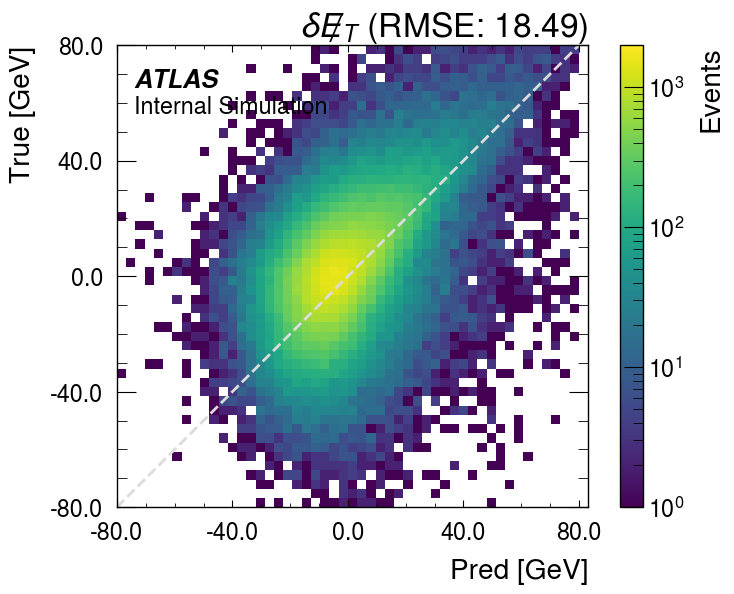

PosixPath('/root/work/ww-pcres/fold_meta_ggF_tuned_v2/figure/dmet_2d.pdf')

In [80]:


true_dinu_p4 = true_nu_p4.sum(axis=1)
pred_dinu_p4 = pred_nu_p4.sum(axis=1)
true_dinu_pt = pt(true_dinu_p4[:, 0], true_dinu_p4[:, 1])
pred_dinu_pt = pt(pred_dinu_p4[:, 0], pred_dinu_p4[:, 1])
met_pt = pt(met[:, 0], met[:, 1])
reco_dinu_pt_1d = plot_1d_hist(met_pt, true_dinu_pt, name=r"$MET$", bins_edges=np.linspace(0, 200, 51), pred_label="Reco", truth_label="Truth")
save_figure(reco_dinu_pt_1d, FIGURE_DIR, "reco_dinu_pt_1d")
reco_dinu_pt_2d = plot_2d_hist(met_pt, true_dinu_pt, name=r"$MET$", bins_edges=np.linspace(0, 200, 51), log=True, vmax=2e3, pred_label="Reco", truth_label="Truth")
save_figure(reco_dinu_pt_2d, FIGURE_DIR, "reco_dinu_pt_2d")
dinu_pt_1d = plot_1d_hist(pred_dinu_pt, true_dinu_pt, name=r"$p_T^{\nu\nu}$", bins_edges=np.linspace(0, 200, 51))
save_figure(dinu_pt_1d, FIGURE_DIR, "dinu_pt_1d")
dinu_pt_2d = plot_2d_hist(pred_dinu_pt, true_dinu_pt, name=r"$p_T^{\nu\nu}$", bins_edges=np.linspace(0, 200, 51), log=True, vmax=2e3)
save_figure(dinu_pt_2d, FIGURE_DIR, "dinu_pt_2d")

true_dmet = pt(met[:, 0], met[:, 1]) - true_dinu_pt
pred_dmet = pt(met[:, 0], met[:, 1]) - pred_dinu_pt
dmet_1d = plot_1d_hist(pred_dmet, true_dmet, name=r"$\delta{{E \not}_{T}}$", bins_edges=np.linspace(-80, 80, 51))
save_figure(dmet_1d, FIGURE_DIR, "dmet_1d")
dmet_2d = plot_2d_hist(pred_dmet, true_dmet, name=r"$\delta{{E \not}_{T}}$", bins_edges=np.linspace(-80, 80, 51), log=True, vmax=2e3)
save_figure(dmet_2d, FIGURE_DIR, "dmet_2d")

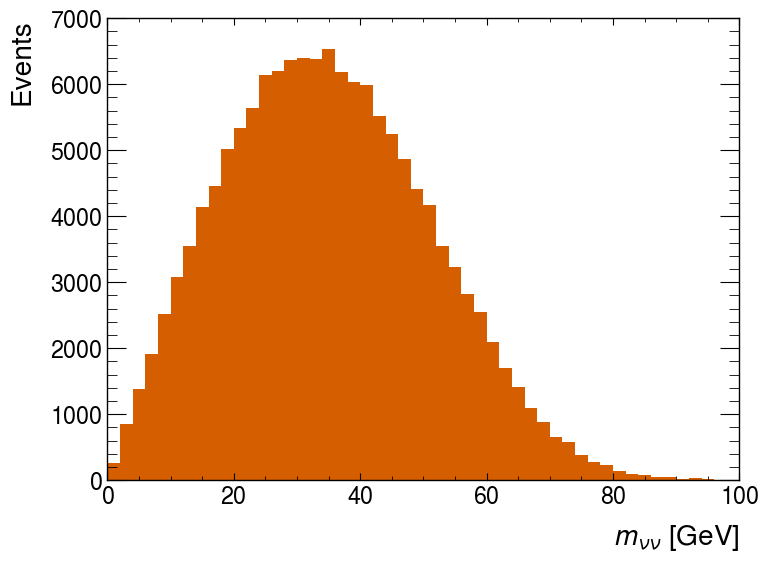

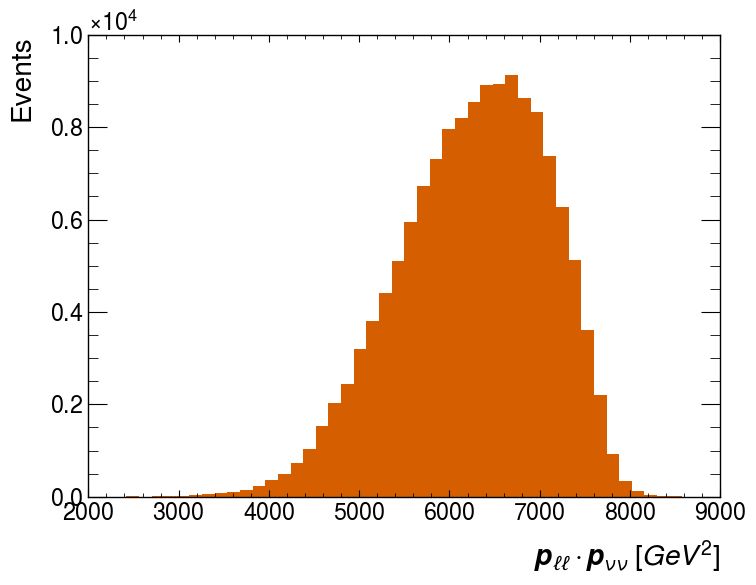

In [81]:
true_dinu_p4 = true_nu_p4.sum(axis=1)
true_dinu_mass = invariant_mass(true_dinu_p4)
fig, ax = plt.subplots()
ax.hist(true_dinu_mass, bins=50, range=(0, 100))
ax.set_xlabel(r"$m_{\nu\nu}$ [GeV]")
ax.set_ylabel("Events")
save_figure(fig, FIGURE_DIR, "true_dinu_mass")
plt.show()

true_dilep_p4 = lep_p4.sum(axis=1)
true_dilep_dinu_dot = true_dilep_p4[:, -1] * true_dinu_p4[:, -1] - np.sum(true_dilep_p4[:, :3] * true_dinu_p4[:, :3], axis=1)
fig, ax = plt.subplots()
ax.hist(true_dilep_dinu_dot, bins=50, range=(2000, 9000))
ax.set_xlabel(r"$\boldsymbol{p}_{\ell\ell} \cdot \boldsymbol{p}_{\nu\nu}$ [$GeV^2$]")
ax.set_ylabel("Events")
save_figure(fig, FIGURE_DIR, "dilepton_dineutrino_dot")
plt.show()

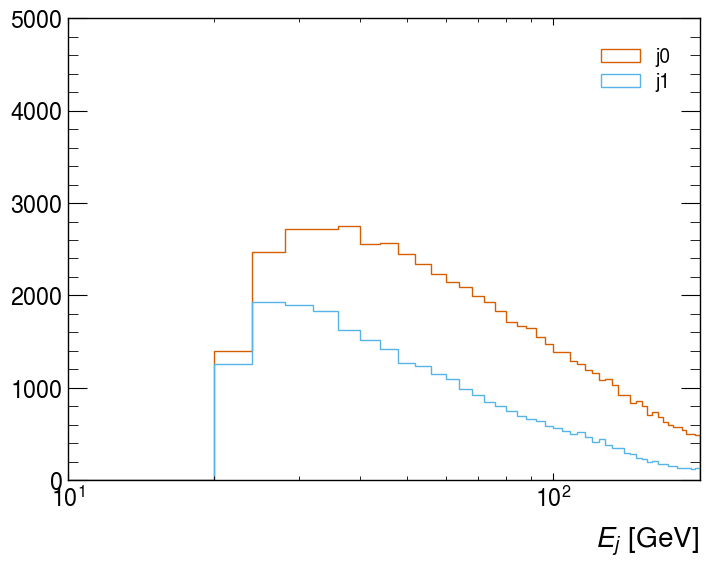

In [82]:
bins_edges = np.linspace(0, 200, 51)
fig, ax = plt.subplots()
for column, label in zip(JET_ENERGY_COLUMNS, ["j0", "j1"]):
    ax.hist(features[:, column], bins=bins_edges, histtype="step", label=label)
ax.set_xscale("log")
ax.set_xlim(10, 200)
ax.set_ylim(0, 5e3)
ax.set_xlabel(r"$E_{j}$ [GeV]")
ax.legend()
save_figure(fig, FIGURE_DIR, "jet_energy")
plt.show()

In [83]:
component_names = [f"W{charge} {axis}" for charge in CHARGES for axis in ["px", "py", "pz", "E"]]
calibration = component_calibration(predictions[:, :8], true_labels[:, :8])

rows = []
for index, name in enumerate(component_names):
    pred = predictions[:, index]
    truth = true_labels[:, index]
    valid = np.isfinite(pred) & np.isfinite(truth)
    rows.append(
        {
            "component": name,
            "pred_mean": pred[valid].mean() if valid.any() else np.nan,
            "truth_mean": truth[valid].mean() if valid.any() else np.nan,
            **{metric: values[index] for metric, values in calibration.items()},
        }
    )

fourvec_diagnostics = pd.DataFrame(rows).set_index("component")
display(fourvec_diagnostics.round(4))

,pred_mean,truth_mean,bias,width_ratio,correlation,slope,intercept,rmse
component,,,,,,,,
W+ px,0.130200,-0.004000,0.1342,0.9244,0.8214,0.7593,0.1332,18.8793
W+ py,0.103800,0.031200,0.0726,0.9153,0.8280,0.7578,0.0802,18.4573
W+ pz,-0.579300,0.126600,-0.7059,0.7236,0.8171,0.5912,-0.6542,84.4202
W+ E,106.985603,126.777199,-19.7915,0.6812,0.7121,0.4851,45.4839,74.8362
W- px,-0.281200,0.024800,-0.3060,0.8933,0.8224,0.7347,-0.2994,18.7448
W- py,0.019300,-0.183500,0.2028,0.8770,0.8207,0.7198,0.1513,18.7523
W- pz,0.199500,0.034100,0.1654,0.7313,0.8203,0.5999,0.1791,83.9385
W- E,107.588600,126.929703,-19.3410,0.6833,0.7184,0.4909,45.2801,74.4831


Mean predicted Higgs mass: 125.00 GeV, Std: 0.00 GeV


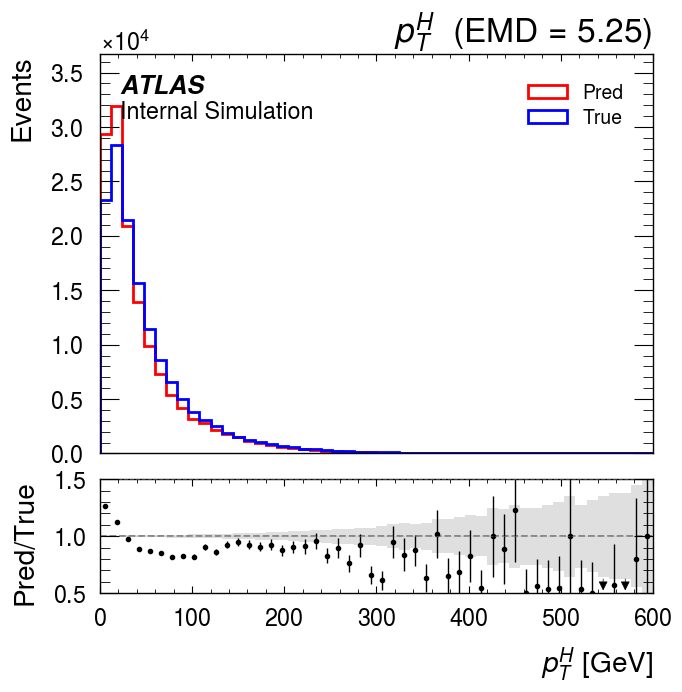

Rel err < 20%: 33.73 %


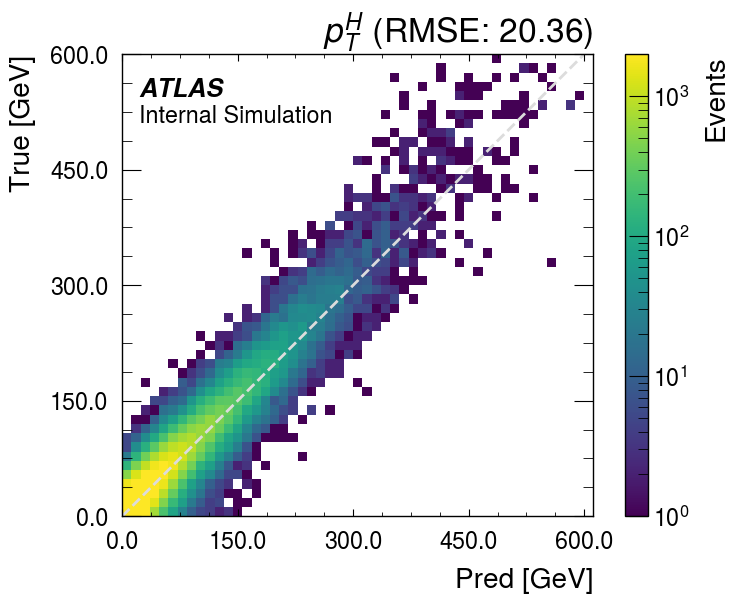

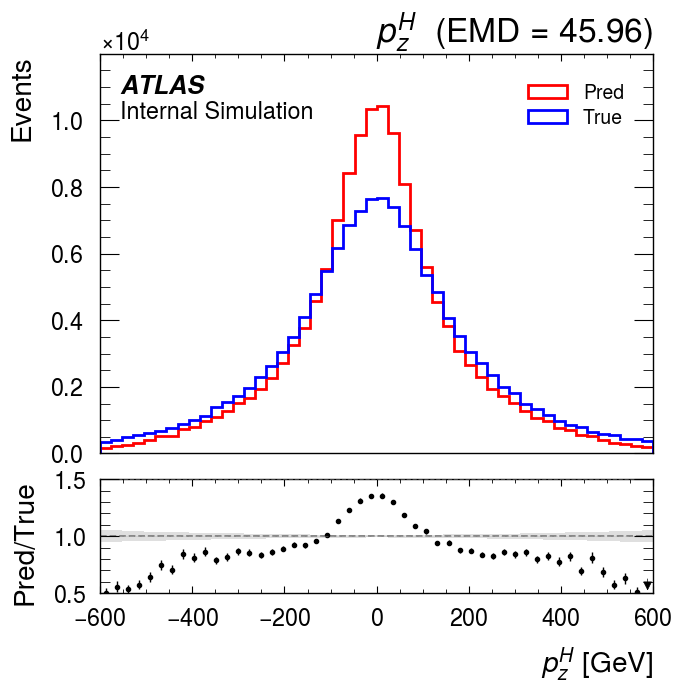

Rel err < 20%: 25.54 %


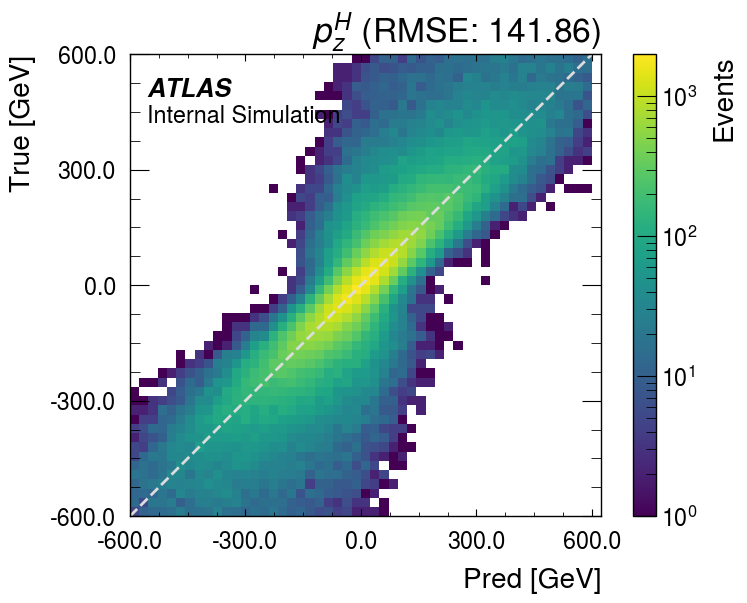

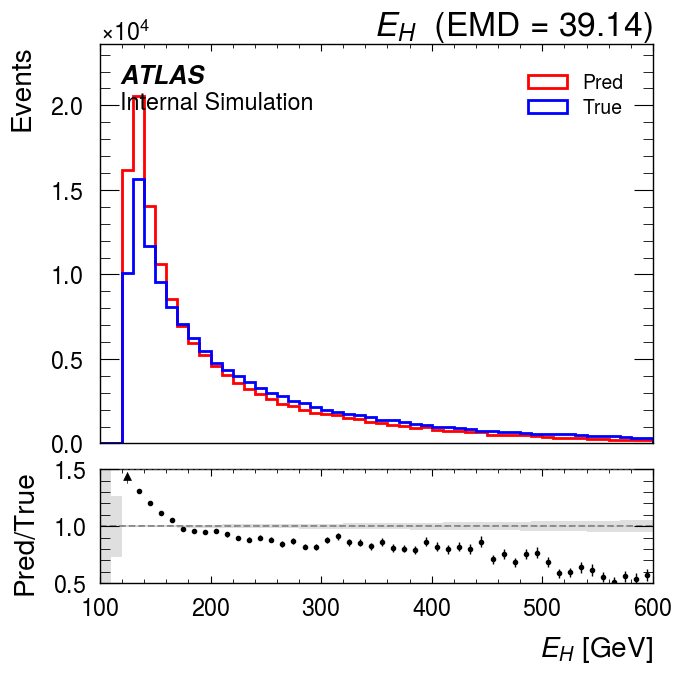

Rel err < 20%: 65.75 %


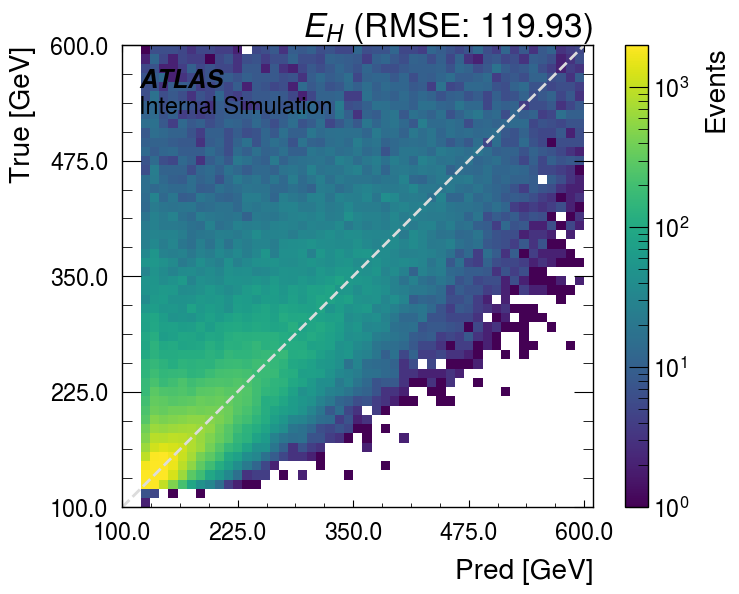

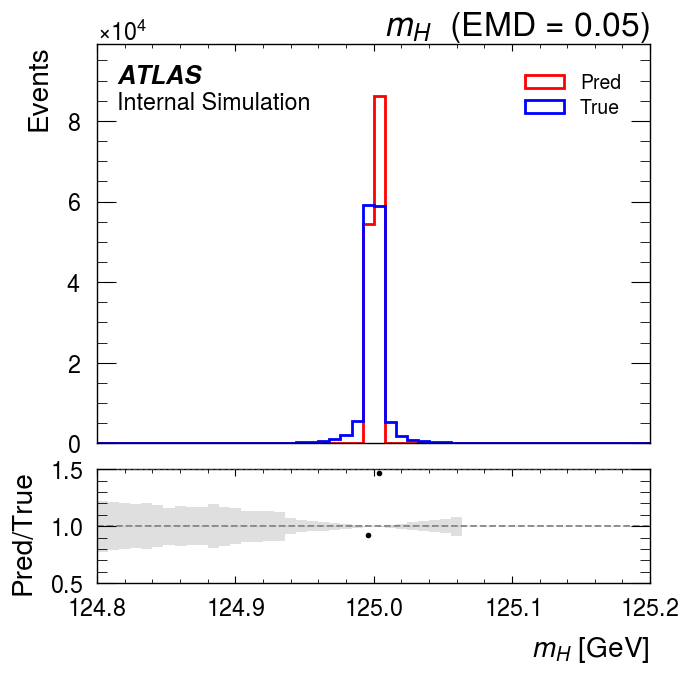

Rel err < 20%: 99.99 %


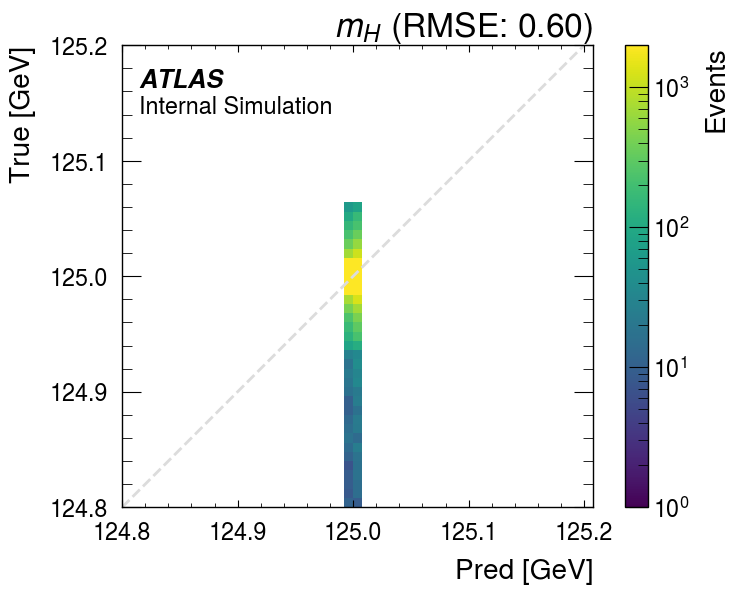

In [84]:
print(
    f"Mean predicted Higgs mass: {pred_higgs_mass.mean():.2f} GeV, "
    f"Std: {pred_higgs_mass.std():.2f} GeV"
)

higgs_observables = [
    (
        pt(pred_higgs_p4[:, 0], pred_higgs_p4[:, 1]),
        pt(true_higgs_p4[:, 0], true_higgs_p4[:, 1]),
        r"$p_T^{H}$",
        np.linspace(0, 600, 51),
        "higgs_pt",
    ),
    (pred_higgs_p4[:, 2], true_higgs_p4[:, 2], r"$p_z^{H}$", np.linspace(-600, 600, 51), "higgs_pz"),
    (pred_higgs_p4[:, 3], true_higgs_p4[:, 3], r"$E_H$", np.linspace(100, 600, 51), "higgs_energy"),
    (pred_higgs_mass, true_higgs_mass, r"$m_H$", np.linspace(124.8, 125.2, 51), "higgs_mass"),
]
for pred, truth, name, bins, filename in higgs_observables:
    save_figure_pair(plot_pair(pred, truth, name, bins), filename)

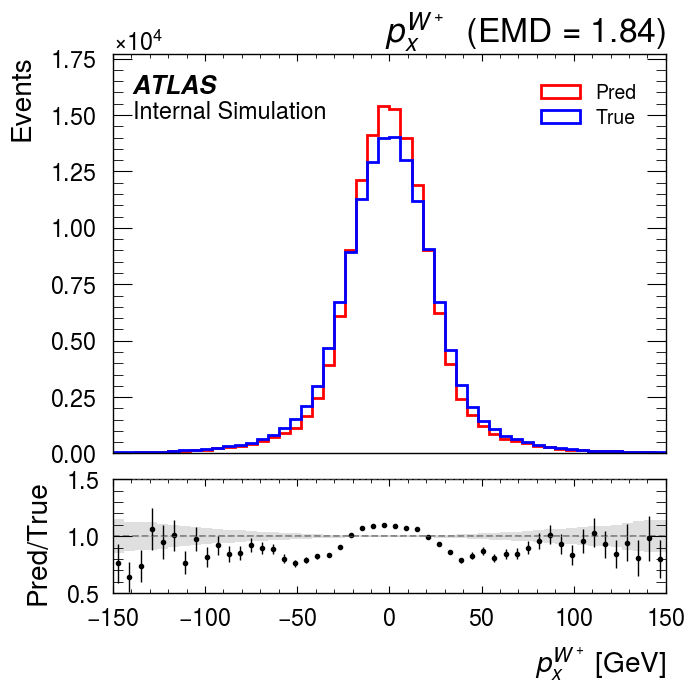

Rel err < 20%: 18.36 %


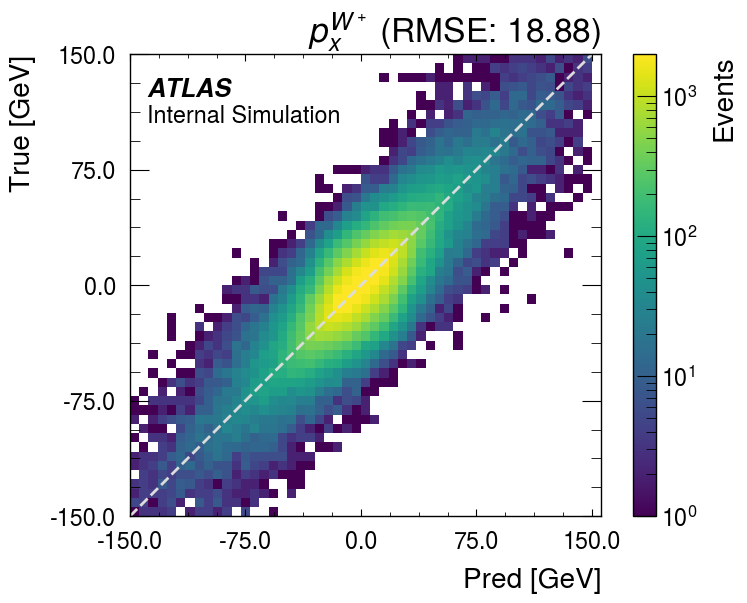

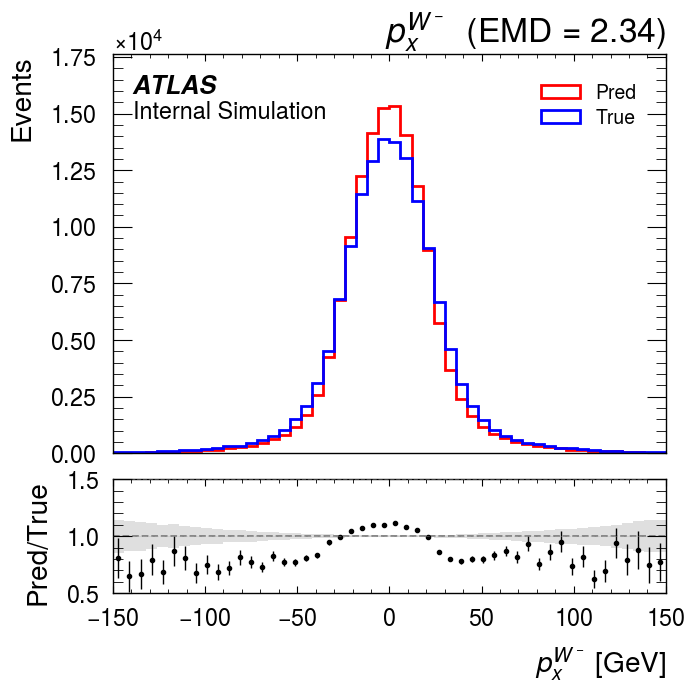

Rel err < 20%: 18.09 %


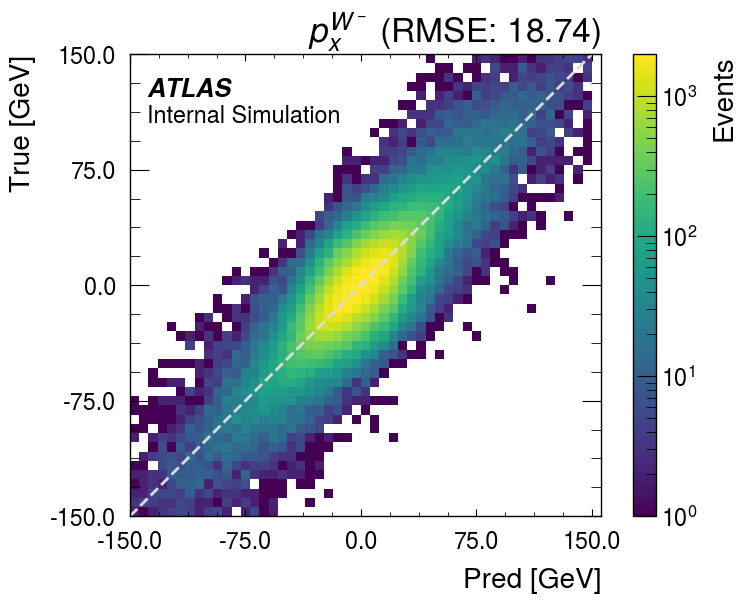

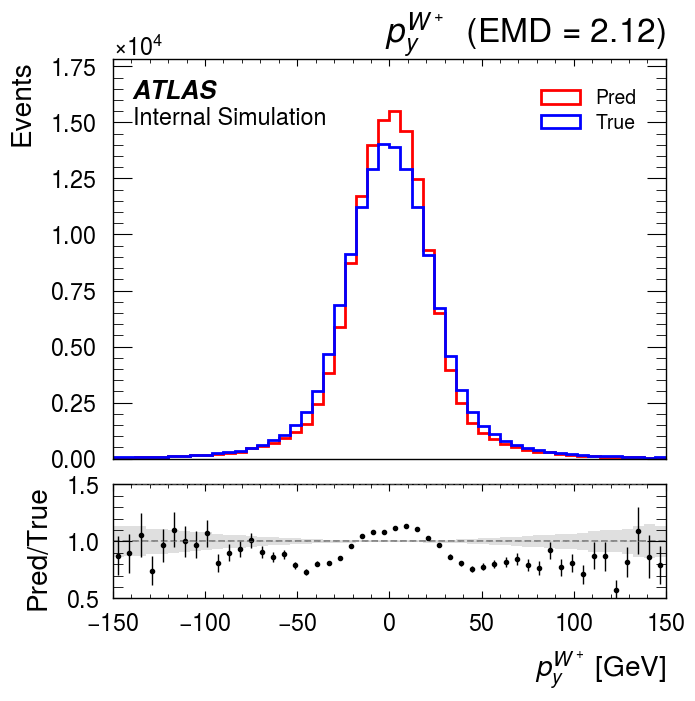

Rel err < 20%: 18.16 %


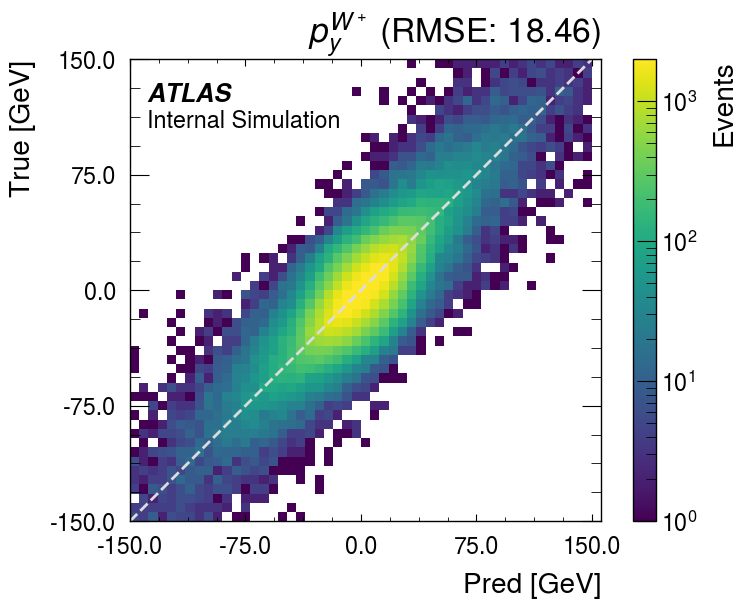

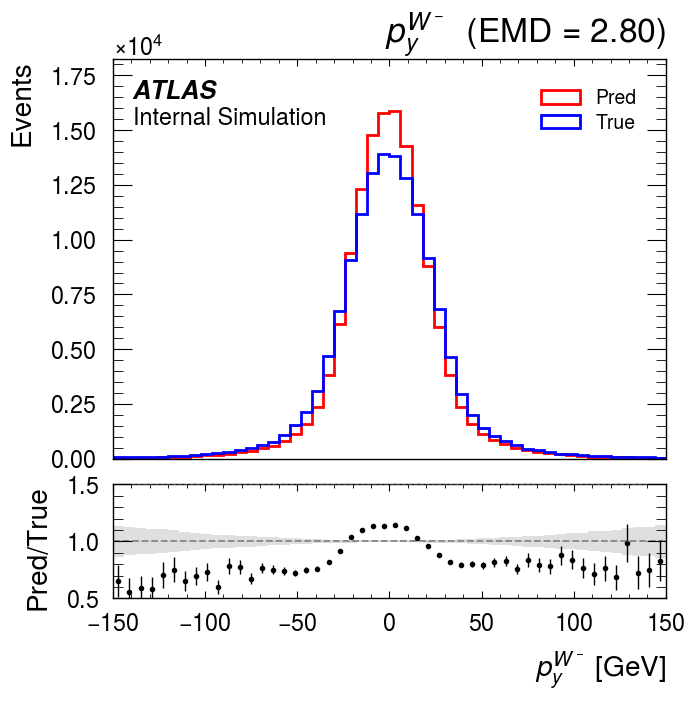

Rel err < 20%: 18.05 %


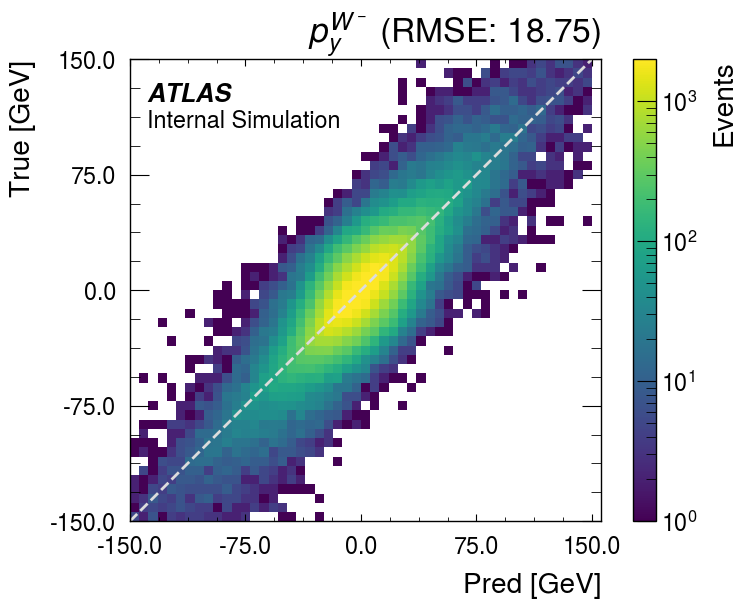

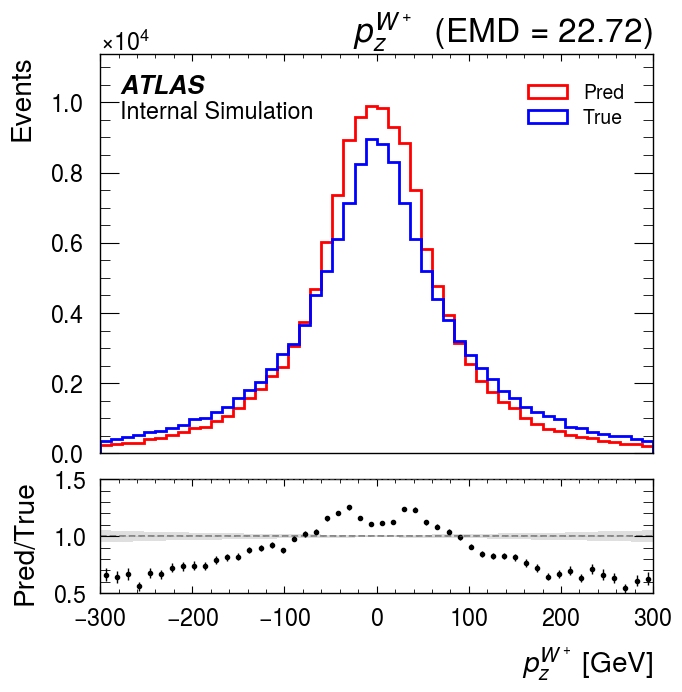

Rel err < 20%: 22.21 %


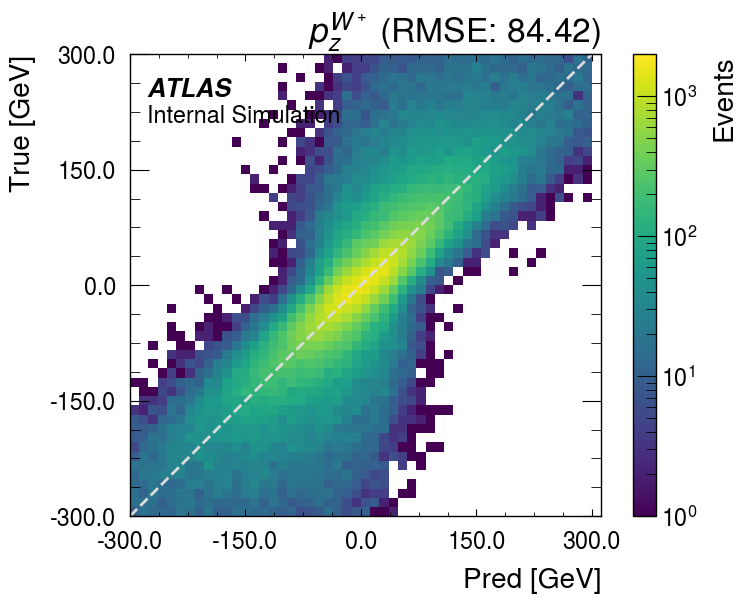

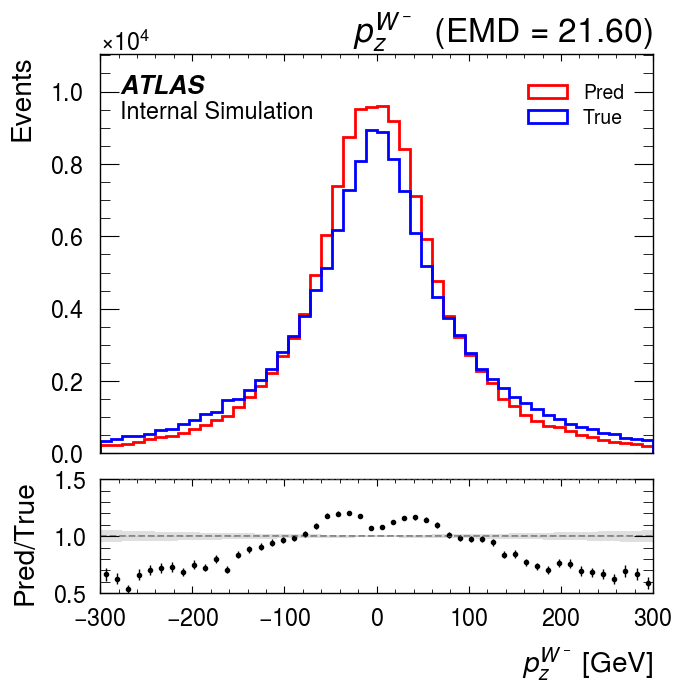

Rel err < 20%: 21.79 %


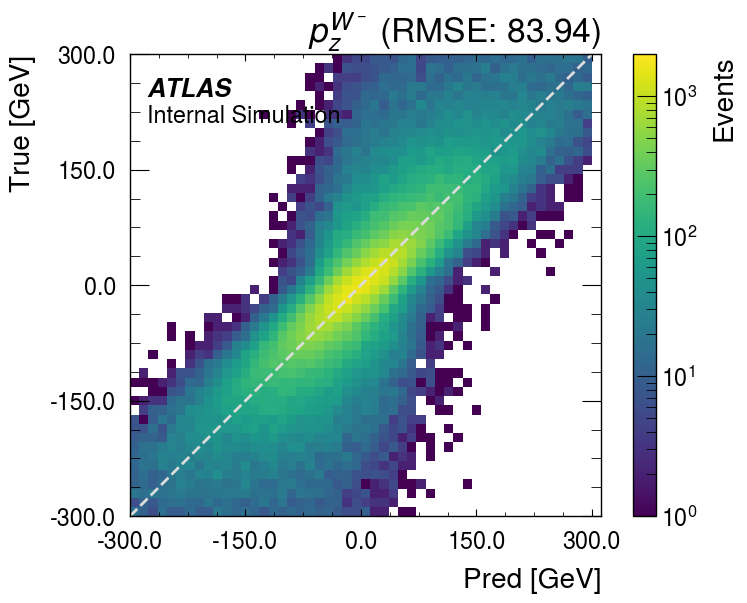

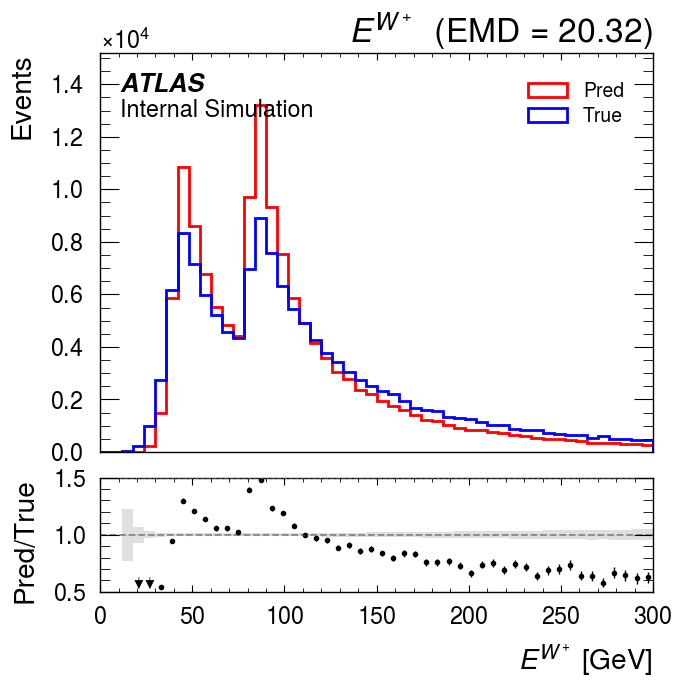

Rel err < 20%: 52.53 %


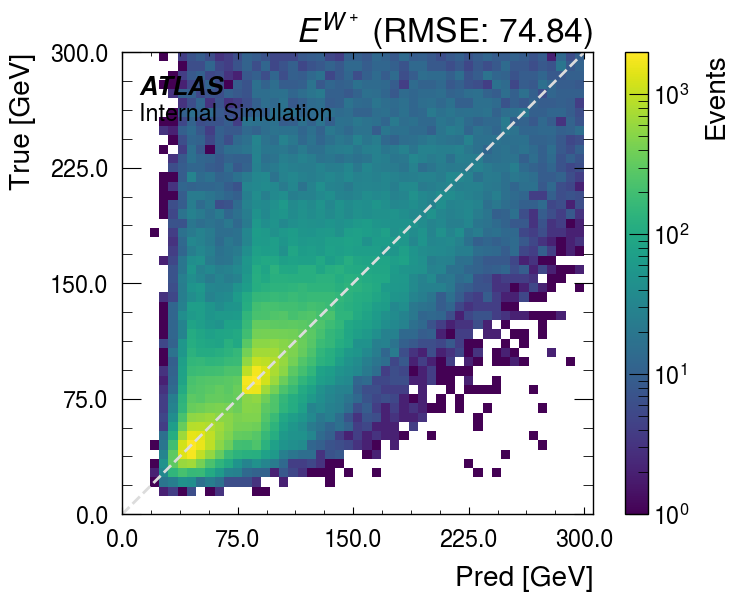

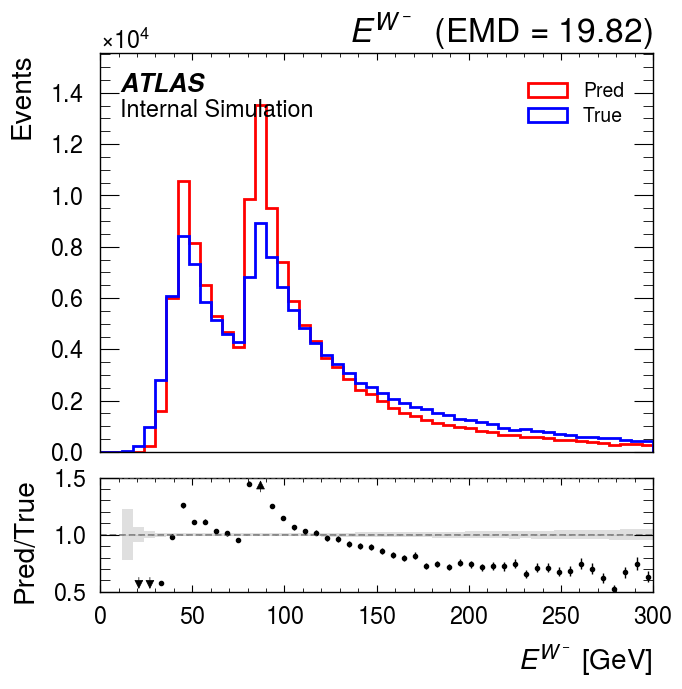

Rel err < 20%: 52.26 %


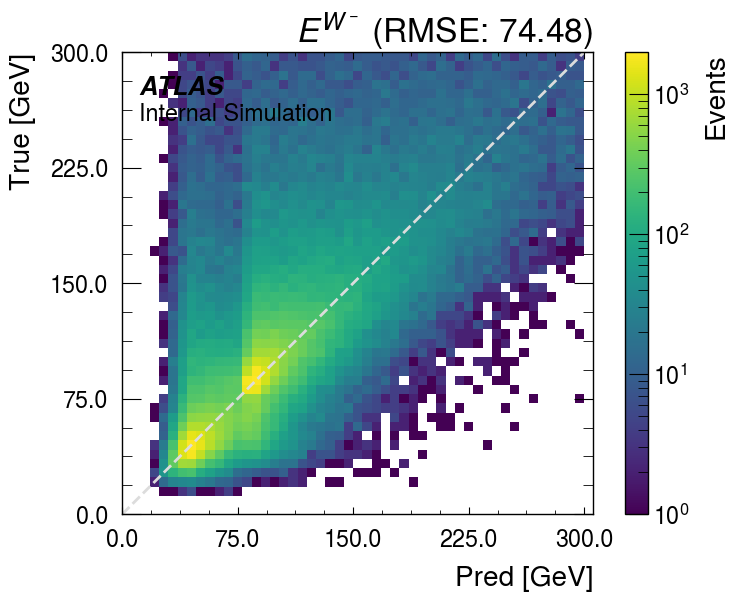

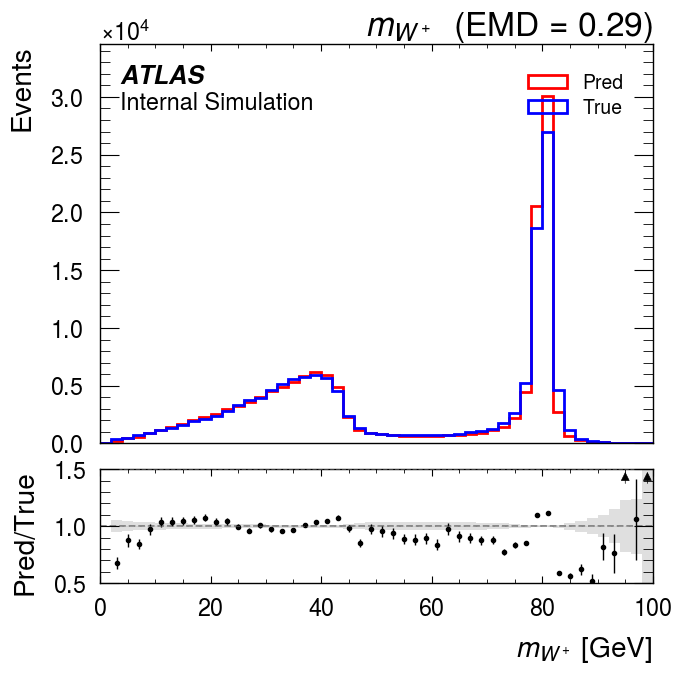

Rel err < 20%: 56.37 %


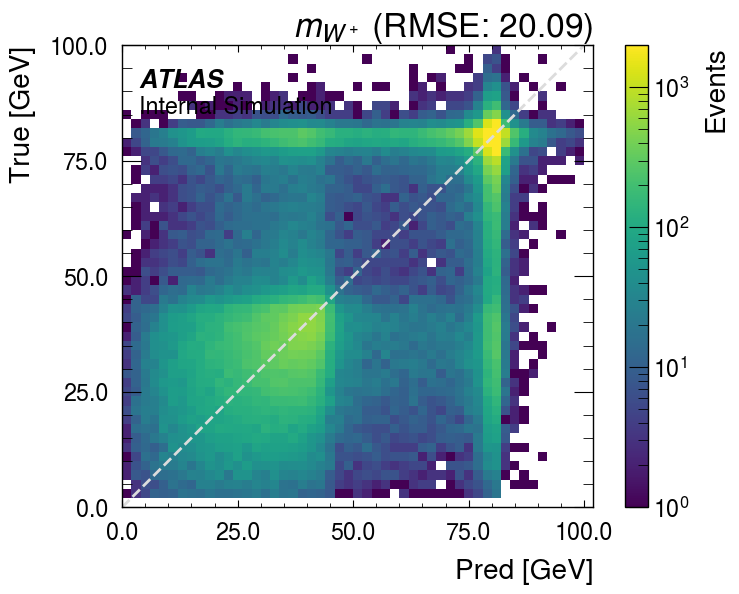

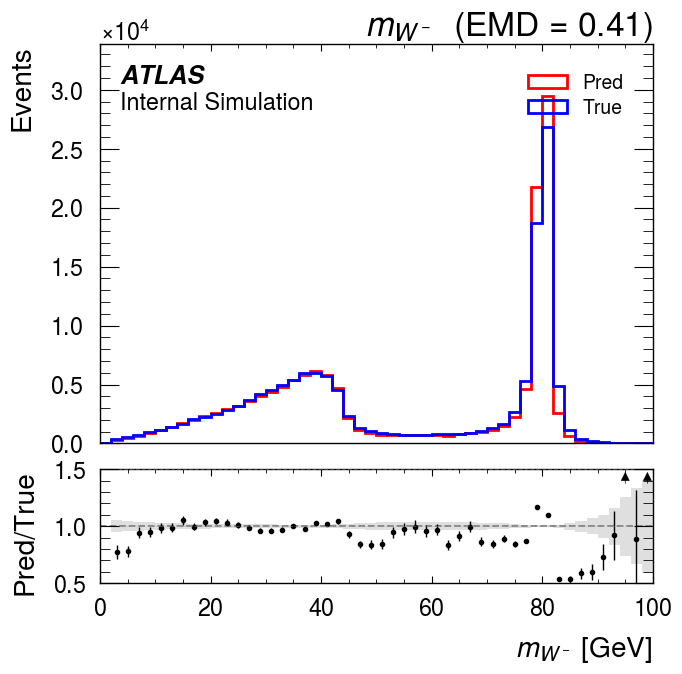

Rel err < 20%: 56.53 %


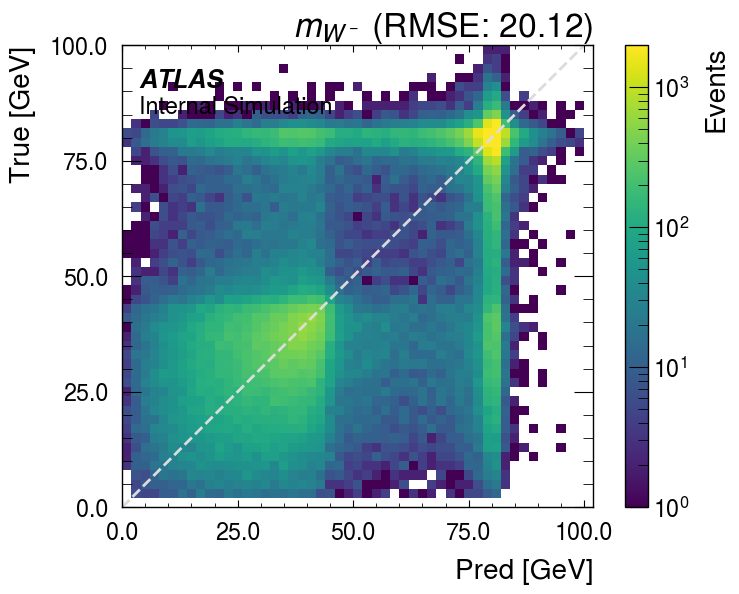

In [85]:
w_components = [
    (0, "p_x", "px", np.linspace(-150, 150, 51)),
    (1, "p_y", "py", np.linspace(-150, 150, 51)),
    (2, "p_z", "pz", np.linspace(-300, 300, 51)),
    (3, "E", "energy", np.linspace(0, 300, 51)),
]

for component, symbol, filename, bins in w_components:
    for index, charge in enumerate(CHARGES):
        charge_name = "plus" if charge == "+" else "minus"
        save_figure_pair(
            plot_pair(
                pred_w_p4[:, index, component],
                true_w_p4[:, index, component],
                rf"${symbol}^{{W^{charge}}}$",
                bins,
            ),
            f"w_{charge_name}_{filename}",
        )

for index, charge in enumerate(CHARGES):
    charge_name = "plus" if charge == "+" else "minus"
    save_figure_pair(
        plot_pair(
            invariant_mass(pred_w_p4[:, index]),
            true_w_mass[:, index],
            rf"$m_{{W^{charge}}}$",
            np.linspace(0, 100, 51),
        ),
        f"w_{charge_name}_mass",
    )

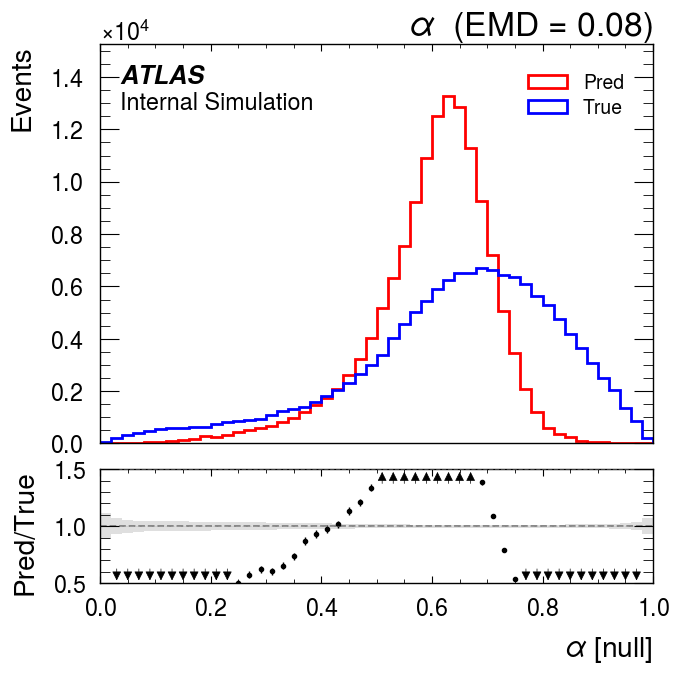

Rel err < 20%: 51.78 %


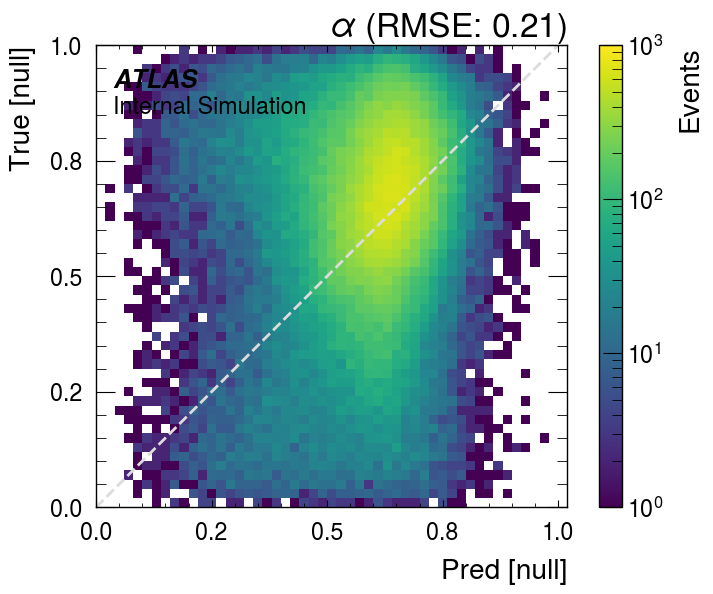

In [86]:
def split_by_mask(p4_pair, mask):
    """Split an (events, 2, 4) pair into (selected, other) with a per-event mask."""
    first, second = p4_pair[:, 0], p4_pair[:, 1]
    mask = mask[:, np.newaxis]
    return np.where(mask, first, second), np.where(mask, second, first)


def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    """Momentum fraction of the neutrino from the heavier lepton + di-neutrino system."""
    dinu_p4 = neu_on_p4 + neu_off_p4
    norm_on = np.linalg.norm(neu_on_p4[:, :3], axis=-1)
    norm_off = np.linalg.norm(neu_off_p4[:, :3], axis=-1)
    on_is_heavier = invariant_mass(lep_on_p4 + dinu_p4) > invariant_mass(lep_off_p4 + dinu_p4)
    return np.where(on_is_heavier, norm_on, norm_off) / (norm_on + norm_off + TOR)


true_on_first = np.abs(true_w_mass[:, 0] ** 2 - W_MASS**2) < np.abs(
    true_w_mass[:, 1] ** 2 - W_MASS**2
)
pred_on_first = np.abs(invariant_mass2(pred_w_p4[:, 0]) - W_MASS**2) < np.abs(
    invariant_mass2(pred_w_p4[:, 1]) - W_MASS**2
)

# The lepton assignment always comes from truth, so pred and truth alpha stay comparable.
lep_on_p4, lep_off_p4 = split_by_mask(lep_p4, true_on_first)
true_w_on_p4, true_w_off_p4 = split_by_mask(true_w_p4, true_on_first)
pred_w_on_p4, pred_w_off_p4 = split_by_mask(pred_w_p4, pred_on_first)

true_alpha = alpha_func(lep_on_p4, true_w_on_p4 - lep_on_p4, lep_off_p4, true_w_off_p4 - lep_off_p4)
pred_alpha = alpha_func(lep_on_p4, pred_w_on_p4 - lep_on_p4, lep_off_p4, pred_w_off_p4 - lep_off_p4)

save_figure_pair(
    plot_pair(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null", vmax=1e3),
    "alpha",
)

In [87]:
def angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device):
    """Lepton (theta, phi) per W rest frame, keeping only events with a valid boost."""
    lep = torch.as_tensor(lep_p4, dtype=torch.float32, device=device)
    true_w = torch.as_tensor(true_w_p4, dtype=torch.float32, device=device)
    pred_w = torch.as_tensor(pred_w_p4, dtype=torch.float32, device=device)

    true_booster = TorchBooster(lep, true_w)
    pred_booster = TorchBooster(lep, pred_w)
    valid = true_booster.valid_rest_frame_mask() & pred_booster.valid_rest_frame_mask()

    true_ang = torch.stack(true_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    pred_ang = torch.stack(pred_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    return true_ang.cpu().numpy(), pred_ang.cpu().numpy(), valid.cpu().numpy()


true_ang, pred_ang, angular_valid = angular_features_like_training(
    features[:, :8], true_labels[:, :8], predictions[:, :8], device
)
print(f"Angular valid events: {angular_valid.sum()} / {len(angular_valid)}")

# Columns 0..3 are (theta+, phi+, theta-, phi-); the booster already wraps phi to (-pi, pi].
true_theta, true_phi = true_ang[:, [0, 2]], true_ang[:, [1, 3]]
pred_theta, pred_phi = pred_ang[:, [0, 2]], pred_ang[:, [1, 3]]

Angular valid events: 140565 / 140565


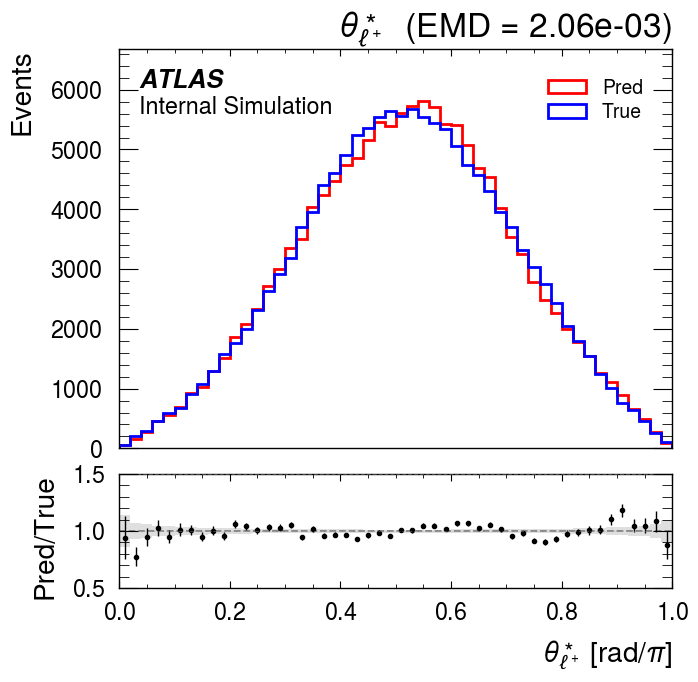

Rel err < 20%: 45.39 %


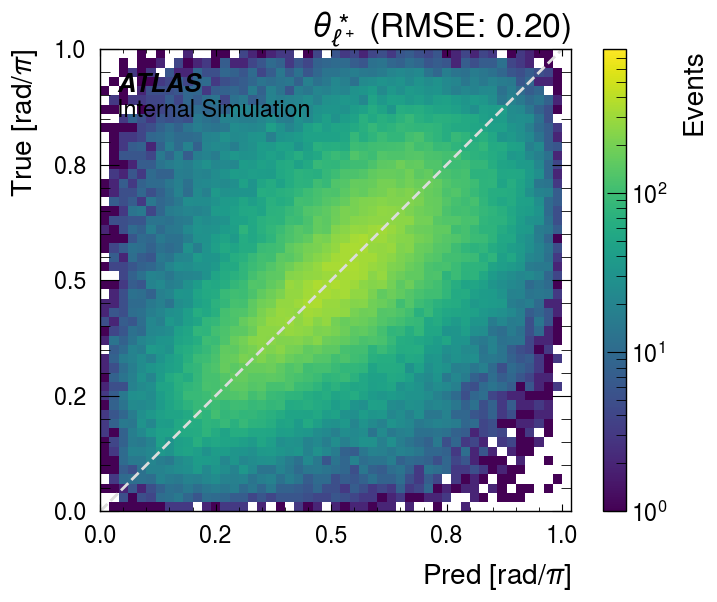

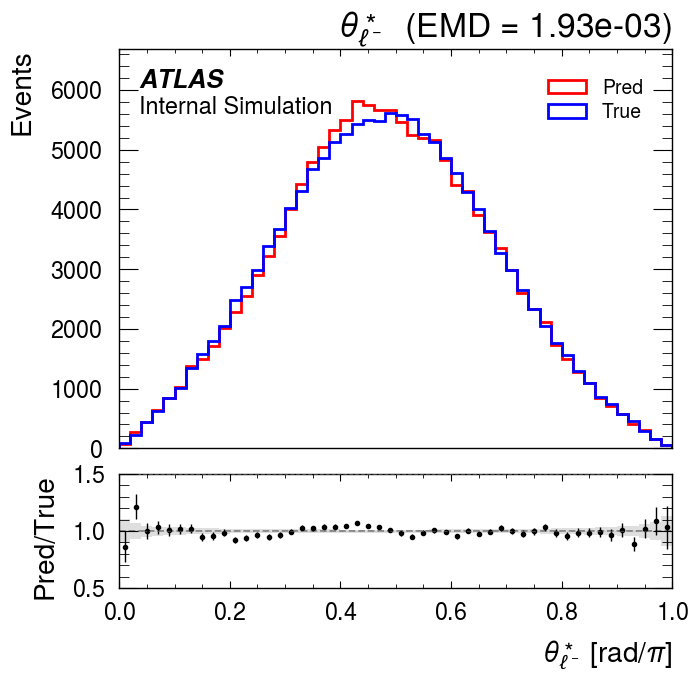

Rel err < 20%: 43.63 %


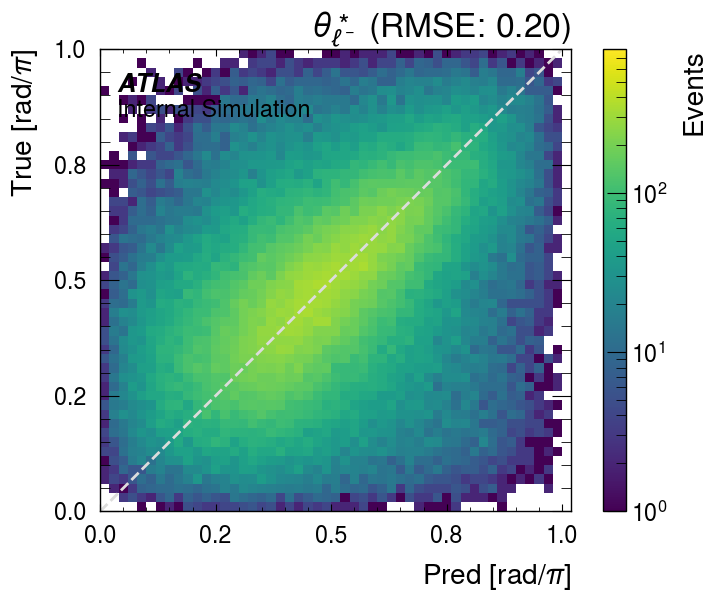

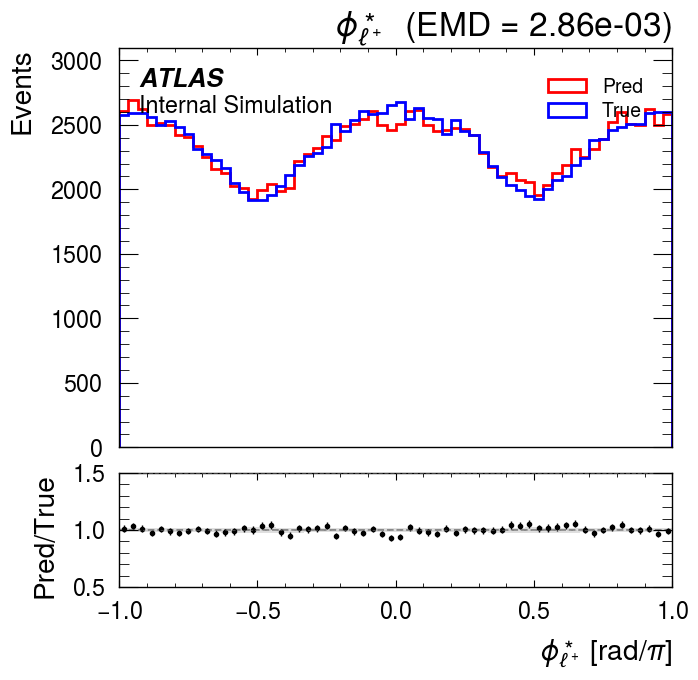

Rel err < 20%: 16.65 %


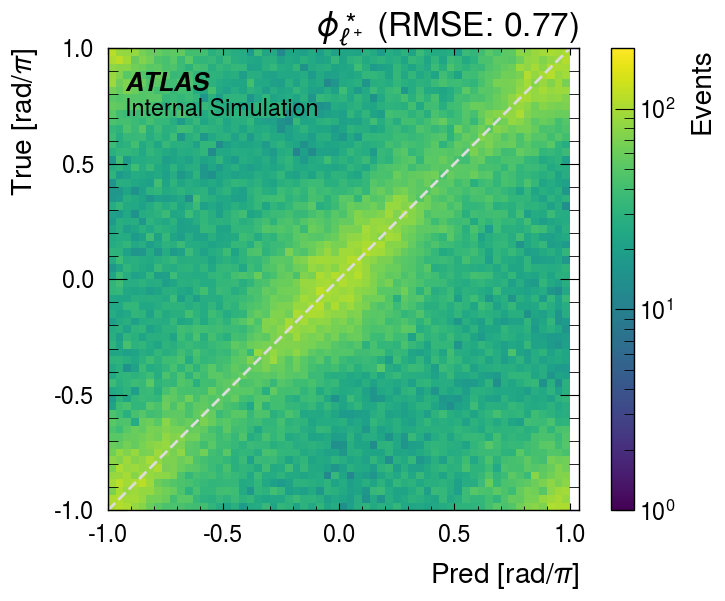

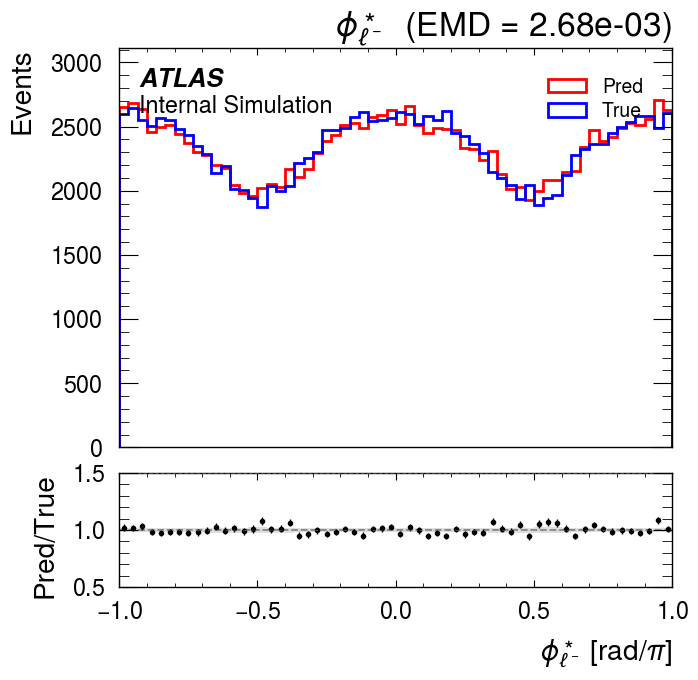

Rel err < 20%: 16.81 %


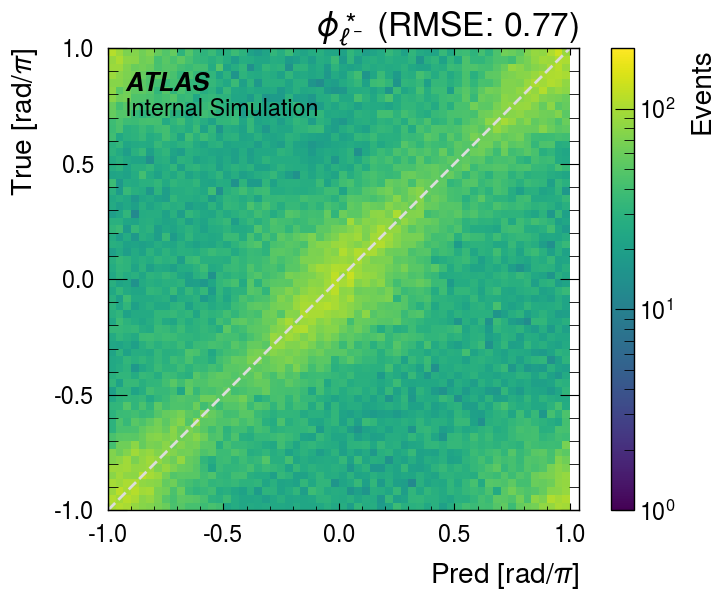

In [88]:
for index, charge in enumerate(CHARGES):
    charge_name = "plus" if charge == "+" else "minus"
    save_figure_pair(
        plot_pair(
            pred_theta[:, index] / np.pi,
            true_theta[:, index] / np.pi,
            rf"$\theta^\ast_{{\ell^{charge}}}$",
            np.linspace(0, 1, 51),
            unit=r"rad/$\pi$",
            vmax=8e2,
        ),
        f"theta_{charge_name}",
    )

for index, charge in enumerate(CHARGES):
    charge_name = "plus" if charge == "+" else "minus"
    save_figure_pair(
        plot_pair(
            pred_phi[:, index] / np.pi,
            true_phi[:, index] / np.pi,
            rf"$\phi^\ast_{{\ell^{charge}}}$",
            np.linspace(-1, 1, 61),
            unit=r"rad/$\pi$",
            vmax=2e2,
        ),
        f"phi_{charge_name}",
    )

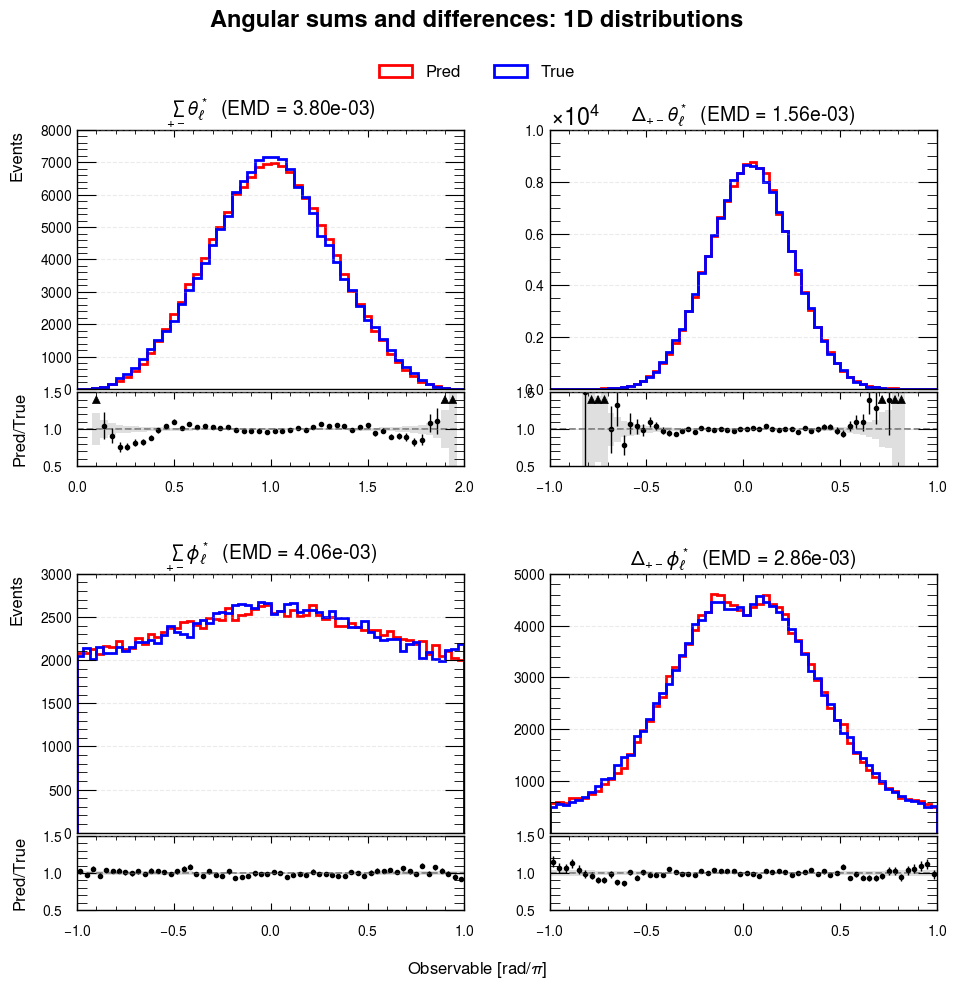

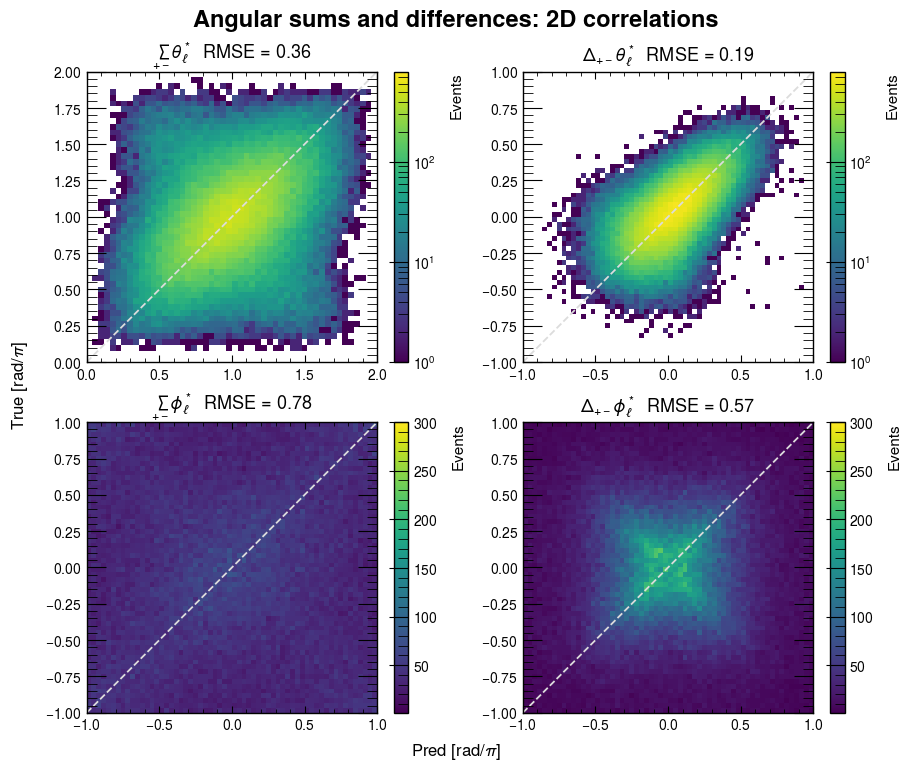

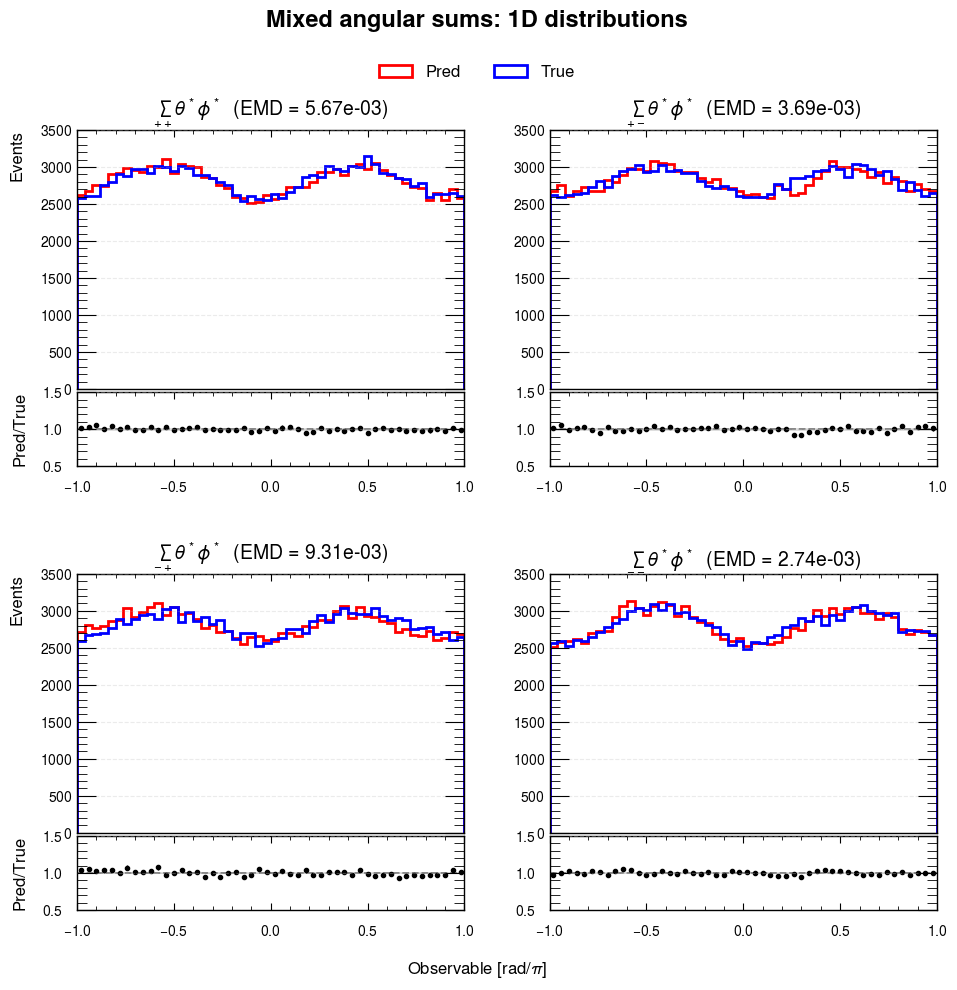

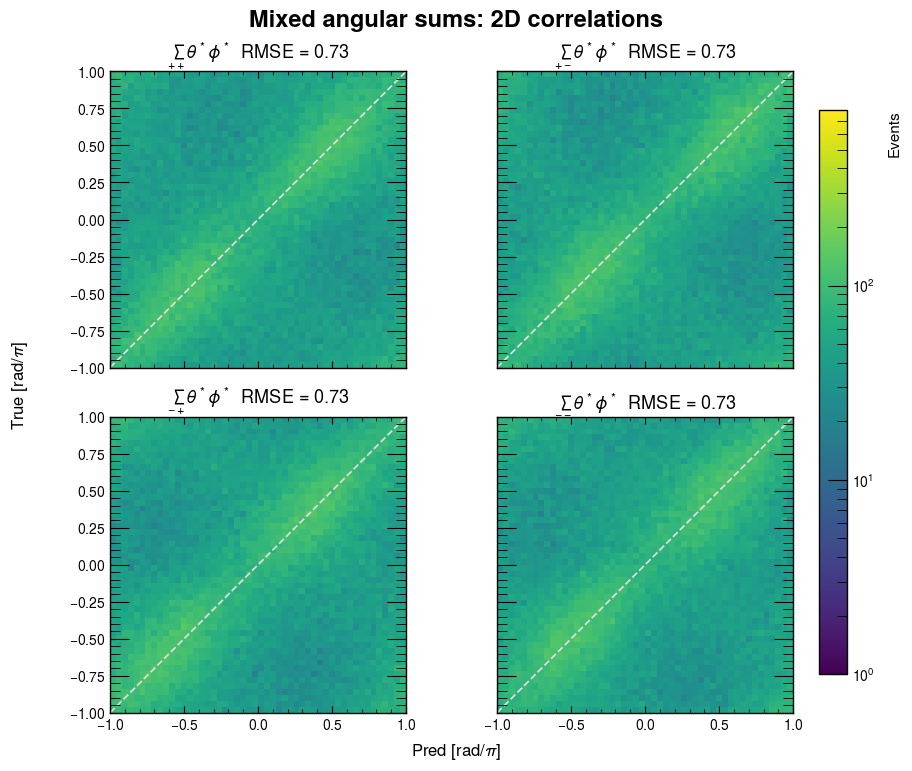

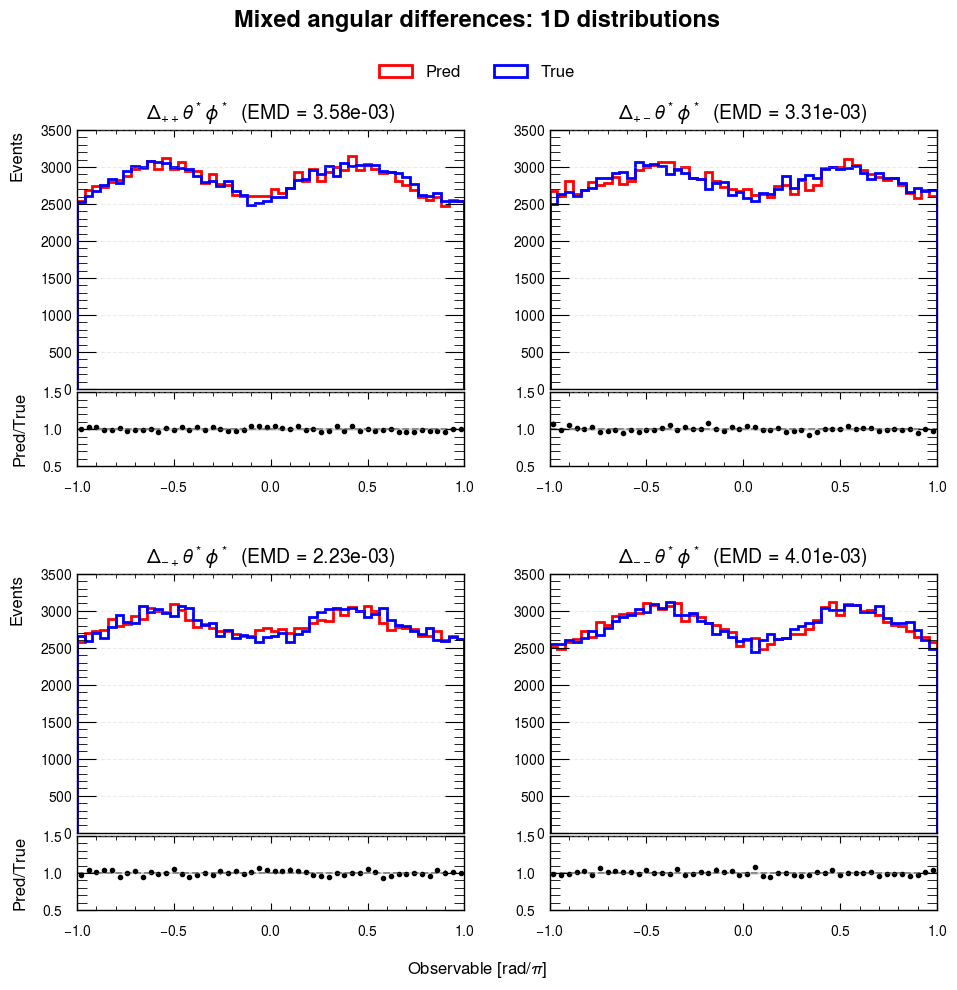

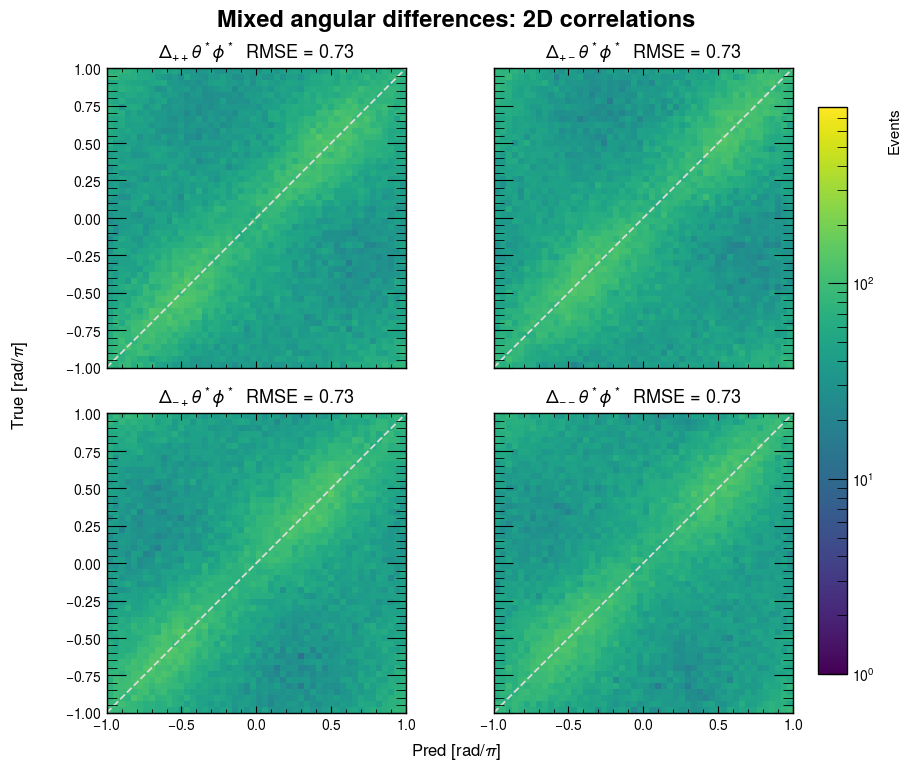

In [89]:
def observable(pred, truth, label, bins, log=True, vmax=8e2):
    return {"pred": pred, "truth": truth, "label": label, "bins": bins, "log": log, "vmax": vmax}


angular_observables = [
    observable(
        pred_theta.sum(axis=1),
        true_theta.sum(axis=1),
        r"$\sum_{+-}\theta^*_{\ell}$",
        np.linspace(0, 2, 51),
    ),
    observable(
        pred_theta[:, 0] - pred_theta[:, 1],
        true_theta[:, 0] - true_theta[:, 1],
        r"$\Delta_{+-}\theta^*_{\ell}$",
        np.linspace(-1, 1, 61),
    ),
    observable(
        sphi(pred_phi[:, 0], pred_phi[:, 1]),
        sphi(true_phi[:, 0], true_phi[:, 1]),
        r"$\sum_{+-}\phi^*_{\ell}$",
        np.linspace(-1, 1, 61),
        log=False,
        vmax=3e2,
    ),
    observable(
        dphi(pred_phi[:, 0], pred_phi[:, 1]),
        dphi(true_phi[:, 0], true_phi[:, 1]),
        r"$\Delta_{+-}\phi^*_{\ell}$",
        np.linspace(-1, 1, 61),
        log=False,
        vmax=3e2,
    ),
]

# Mixed observables combine the theta of one lepton with the phi of either lepton.
MIXED_BINS = np.linspace(-1, 1, 51)
mixed_sum_observables = [
    observable(
        sphi(pred_theta[:, i], pred_phi[:, j]),
        sphi(true_theta[:, i], true_phi[:, j]),
        rf"$\sum_{{{CHARGES[i]}{CHARGES[j]}}}\theta^*\phi^*$",
        MIXED_BINS,
    )
    for i in range(2)
    for j in range(2)
]
mixed_diff_observables = [
    observable(
        dphi(pred_theta[:, i], pred_phi[:, j]),
        dphi(true_theta[:, i], true_phi[:, j]),
        rf"$\Delta_{{{CHARGES[i]}{CHARGES[j]}}}\theta^*\phi^*$",
        MIXED_BINS,
    )
    for i in range(2)
    for j in range(2)
]

angular_grids = [
    ("Angular sums and differences", "angular_sums_differences", angular_observables, False),
    ("Mixed angular sums", "mixed_angular_sums", mixed_sum_observables, True),
    ("Mixed angular differences", "mixed_angular_differences", mixed_diff_observables, True),
]
# The mixed grids share axes and one colorbar because their four panels share binning.
for title, filename, observables, shared in angular_grids:
    figure_1d, _ = plot_angular_1d_grid(
        observables, f"{title}: 1D distributions", share_axes=shared
    )
    save_figure(figure_1d, FIGURE_DIR, f"{filename}_1d")
    figure_2d, _ = plot_angular_2d_grid(
        observables, f"{title}: 2D correlations", share_axes=shared, shared_colorbar=shared
    )
    save_figure(figure_2d, FIGURE_DIR, f"{filename}_2d")

In [90]:
# Fold convergence check. k_fold_train.py rotates the validation split only, so every
# fold shares this test set: each fold checkpoint is scored on the events already loaded
# above, against the truth and against the other folds.
from itertools import combinations

from scipy.stats import wasserstein_distance

# The angular distributions are the ones the folds have to agree on; False adds the W and
# Higgs kinematics to the same tables. PER_FOLD_TABLES prints the full fold-by-fold grid.
ANGULAR_ONLY = True
PER_FOLD_TABLES = False

fold_dirs = sorted(RUN_DIR.glob("fold*"), key=lambda path: int(path.name.removeprefix("fold")))
expected_folds = cfg["parameters"].get("folds", len(fold_dirs))


def fold_checkpoint(fold_dir):
    """Best checkpoint of one fold, chosen the way the single-model cell chooses one."""
    paths = sorted(
        (fold_dir / "logs").glob("version_*/checkpoints/*.ckpt"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    candidates = [path for path in paths if path.name != "last.ckpt"] or paths
    if not candidates:
        return None
    return (best_ckpt_by_metric(candidates, cfg) or (candidates[0], "most recent"))[0]


def predict_fold(checkpoint, feature_array, batch_size=8192):
    """Predictions of one fold checkpoint over the test features, in the same row order."""
    fold_model = LightningWBoson.load_from_checkpoint(
        str(checkpoint), weights_only=False, strict=False
    )
    fold_model.eval()
    fold_model.to(device)

    batches = []
    with torch.no_grad():
        for start in range(0, len(feature_array), batch_size):
            inputs = torch.as_tensor(
                feature_array[start : start + batch_size], dtype=torch.float32, device=device
            )
            batches.append(fold_model(inputs).cpu().numpy())

    del fold_model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return np.concatenate(batches, axis=0)


def rest_frame_angles(values):
    """Lepton (theta*, phi*) per charge, NaN on events without a valid rest frame."""
    _, angles, valid = angular_features_like_training(
        features[:, :8], true_labels[:, :8], values[:, :8], device
    )
    # The booster returns eight angle columns; 0..3 are (theta+, phi+, theta-, phi-).
    filled = np.full((len(values), angles.shape[1]), np.nan)
    filled[valid] = angles
    return filled[:, [0, 2]], filled[:, [1, 3]]


def fold_observables(values):
    """Per-event observables of one (events, 10) prediction or target block, by label."""
    w_p4 = four_vector_pairs(values[:, 0:8])
    higgs_p4 = w_p4.sum(axis=1)
    on_first = np.abs(invariant_mass2(w_p4[:, 0]) - W_MASS**2) < np.abs(
        invariant_mass2(w_p4[:, 1]) - W_MASS**2
    )
    w_on_p4, w_off_p4 = split_by_mask(w_p4, on_first)
    theta, phi = rest_frame_angles(values)

    observables = {}
    for index, charge in enumerate(CHARGES):
        for axis, symbol in enumerate(["px", "py", "pz", "E"]):
            observables[f"W{charge} {symbol}"] = w_p4[:, index, axis]
    for index, charge in enumerate(CHARGES):
        observables[f"m_W{charge}"] = invariant_mass(w_p4[:, index])
    observables["m_H"] = invariant_mass(higgs_p4)
    observables["pT_H"] = pt(higgs_p4[:, 0], higgs_p4[:, 1])
    # The lepton assignment comes from truth here too, so alpha stays comparable.
    observables["alpha"] = alpha_func(
        lep_on_p4, w_on_p4 - lep_on_p4, lep_off_p4, w_off_p4 - lep_off_p4
    )
    # Same angular observables as the 1D/2D grids above, in radians.
    for index, charge in enumerate(CHARGES):
        observables[f"theta*_l{charge}"] = theta[:, index]
    for index, charge in enumerate(CHARGES):
        observables[f"phi*_l{charge}"] = phi[:, index]
    observables["sum theta*"] = theta.sum(axis=1)
    observables["diff theta*"] = theta[:, 0] - theta[:, 1]
    observables["sum phi*"] = sphi(phi[:, 0], phi[:, 1])
    observables["diff phi*"] = dphi(phi[:, 0], phi[:, 1])
    return observables


def compare(first, second):
    """RMSE over the paired events plus KS and EMD between the two distributions."""
    paired = np.isfinite(first) & np.isfinite(second)
    if not paired.any():
        return {"rmse": np.nan, "ks": np.nan, "emd": np.nan, "events": 0}
    left, right = first[paired], second[paired]
    return {
        "rmse": float(np.sqrt(np.mean((left - right) ** 2))),
        "ks": float(ks_2samp(left, right).statistic),
        "emd": float(wasserstein_distance(left, right)),
        "events": int(paired.sum()),
    }


truth_observables = fold_observables(true_labels)
angular_names = [name for name in truth_observables if "theta*" in name or "phi*" in name]
report_names = angular_names if ANGULAR_ONLY else list(truth_observables)

fold_predictions = {}
fold_rows = []
for fold_dir in fold_dirs:
    checkpoint = fold_checkpoint(fold_dir)
    if checkpoint is None:
        print(f"{fold_dir.name}: no checkpoint yet, skipped")
        continue
    fold_values = predict_fold(checkpoint, all_features)[selection]
    fold_predictions[fold_dir.name] = fold_observables(fold_values)
    fold_rows.append(
        {
            "fold": fold_dir.name,
            "epoch": int(checkpoint.stem.split("epoch=")[1].split("-")[0]),
            "w_fourvec_rmse": float(
                np.sqrt(np.mean((fold_values[:, :8] - true_labels[:, :8]) ** 2))
            ),
        }
    )

folds = list(fold_predictions)
if not folds:
    raise FileNotFoundError(f"No fold checkpoints found under {RUN_DIR}")
fold_pairs = list(combinations(folds, 2))
print(f"Scored {len(folds)} / {expected_folds} folds on {len(true_labels)} shared test events.")

# --- One row per observable: quality against truth, and spread between the folds ------
truth_scores = {
    fold: {name: compare(values[name], truth_observables[name]) for name in report_names}
    for fold, values in fold_predictions.items()
}

summary_rows = []
for name in report_names:
    scores = [truth_scores[fold][name] for fold in folds]
    rmse = np.array([score["rmse"] for score in scores])
    ks = np.array([score["ks"] for score in scores])
    emd = np.array([score["emd"] for score in scores])
    pair_scores = [
        compare(fold_predictions[left][name], fold_predictions[right][name])
        for left, right in fold_pairs
    ]
    # Two-sample KS 95% critical value: a fold pair below it is statistically indistinguishable.
    events = min(score["events"] for score in scores)
    summary_rows.append(
        {
            "observable": name,
            "rmse": rmse.mean(),
            "rmse_spread": np.ptp(rmse),
            "ks": ks.mean(),
            "emd": emd.mean(),
            "max_pair_ks": max((score["ks"] for score in pair_scores), default=np.nan),
            "max_pair_emd": max((score["emd"] for score in pair_scores), default=np.nan),
            "ks_noise": 1.36 * np.sqrt(2.0 / events) if events else np.nan,
        }
    )

convergence = pd.DataFrame(summary_rows).set_index("observable")
print(
    f"\nAgainst truth: mean over folds (rmse_spread = max - min across folds). "
    f"Between folds: worst of the {len(fold_pairs)} pairs. Angles in radians."
)
display(convergence.round(4))

# Per fold, the headline angular numbers, to spot a single fold pulling away.
fold_summary = pd.DataFrame(fold_rows).set_index("fold")
for metric in ("rmse", "ks", "emd"):
    fold_summary[f"angular_{metric}"] = [
        np.mean([truth_scores[fold][name][metric] for name in report_names]) for fold in folds
    ]
print("\nPer fold, averaged over the reported observables")
display(fold_summary.round(4))

converged = convergence["max_pair_ks"] <= convergence["ks_noise"]
worst = convergence["max_pair_ks"].idxmax()
print(
    f"\nFolds statistically indistinguishable on {int(converged.sum())} / {len(convergence)} "
    f"observables (max pairwise KS below the noise floor). Worst: {worst} with "
    f"max pairwise KS = {convergence.loc[worst, 'max_pair_ks']:.4f} "
    f"vs noise {convergence.loc[worst, 'ks_noise']:.4f}."
)

if PER_FOLD_TABLES:
    for metric in ("rmse", "ks", "emd"):
        table = pd.DataFrame(
            {
                fold: {name: scores[name][metric] for name in report_names}
                for fold, scores in truth_scores.items()
            }
        ).reindex(report_names)
        table["mean"] = table[folds].mean(axis=1)
        table["spread"] = np.ptp(table[folds].to_numpy(), axis=1)
        print(f"\n{metric.upper()} of each fold against the truth")
        display(table.round(4))

Using 3 SA blocks; connected context dimension: 1080
Using 3 SA blocks; connected context dimension: 1080
Scored 2 / 8 folds on 140565 shared test events.

Against truth: mean over folds (rmse_spread = max - min across folds). Between folds: worst of the 1 pairs. Angles in radians.


,rmse,rmse_spread,ks,emd,max_pair_ks,max_pair_emd,ks_noise
observable,,,,,,,
theta*_l+,0.6367,0.0057,0.0066,0.0056,0.0041,0.0034,0.0051
theta*_l-,0.6331,0.0031,0.0072,0.0061,0.0024,0.0017,0.0051
phi*_l+,2.4106,0.0082,0.0041,0.0075,0.0038,0.0079,0.0051
phi*_l-,2.4114,0.0061,0.0049,0.0095,0.0023,0.0052,0.0051
sum theta*,1.1278,0.0104,0.0062,0.0134,0.0029,0.0048,0.0051
diff theta*,0.5836,0.0012,0.0040,0.0049,0.0047,0.0047,0.0051
sum phi*,2.4401,0.0024,0.0058,0.0133,0.0020,0.0035,0.0051
diff phi*,1.7792,0.0005,0.0047,0.0094,0.0032,0.0058,0.0051



Per fold, averaged over the reported observables


,epoch,w_fourvec_rmse,angular_rmse,angular_ks,angular_emd
fold,,,,,
fold0,184,57.7935,1.5006,0.0056,0.0086
fold1,108,58.1637,1.5050,0.0053,0.0089



Folds statistically indistinguishable on 8 / 8 observables (max pairwise KS below the noise floor). Worst: diff theta* with max pairwise KS = 0.0047 vs noise 0.0051.
